In [1]:
import os, copy
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import interpax
from scipy.interpolate import interp1d

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

from godmax.get_Cls  import get_Cl
from godmax.get_covs import get_cov
from godmax.base_class import get_vmapped_func_warg
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz

from tSZxEuclid.godmax.config.loader import merge_params
from tSZxEuclid.godmax.sampling.ell  import setup_ell_arrays

import diag_utils


import copy as _copy, time as _time
import arviz as az
import jax as _jax
import jax.numpy as _jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from getdist import MCSamples
from getdist import plots as gd_plots
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

# ── Anchor: directory containing this notebook ───────────────────────────────
HERE = Path().resolve()          
DEVELOP = HERE.parents[2]        

# ── Parameter files (diagnostics/params/) ────────────────────────────────────
PARAM_DIR = HERE / 'params'
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = merge_params(
    str(PARAM_DIR / 'params_default.yaml'),
    str(PARAM_DIR / 'params.yaml'),
)

halo_params_dict['lowpass_Pmm1h_lowk'] = True
halo_params_dict['kthresh_lowpass_Pmm1h_lowk'] = 0.01  # k in h/Mpc below which 1h is suppressed                          
analysis_dict['is_cmb_lensing'] = True          

# ── Cosmology (jax_cosmo) ────────────────────────────────────────────────────
cosmo_params = sim_params_dict['cosmo']
cosmo_jax = Cosmology(
    Omega_c  = cosmo_params['Om0'] - cosmo_params['Ob0'],
    Omega_b  = cosmo_params['Ob0'],
    h        = cosmo_params['H0'] / 100.,
    sigma8   = cosmo_params['sigma8'],
    n_s      = cosmo_params['ns'],
    Omega_k  = 0.,
    w0       = cosmo_params.get('w0', -1.0),
    wa       = 0.,
)

# ── ell array (mutates analysis_dict and halo_params_dict in place) ──────────
setup_ell_arrays(analysis_dict, halo_params_dict, lmin=80.0, lmax=3000.0, dl_log=0.02025851)
print(f"nell = {len(analysis_dict['l_array_survey'])}, "
      f"ell range [{float(analysis_dict['l_array_survey'][0]):.1f}, "
      f"{float(analysis_dict['l_array_survey'][-1]):.1f}]")

# ── Galaxy n(z) paths ────────────────────────────────────────────────────────
DNDZ_DIR = DEVELOP / 'tSZxEuclid' / 'Data' / 'dndz'

def to_comoving_nz(z_array, nz_array, cosmo):
    """Convert non-normalised n(z) [#gal/z] to comoving n(z) [(Mpc/h)^-3]."""
    a = 1.0 / (1.0 + z_array)
    chi = radial_comoving_distance(cosmo, a)
    dchi_dz = (2.998e5) / bkgrd.H(cosmo, a)   # c [km/s] / H(a) [km/s/(Mpc/h)]
    dV_dzdOmega = chi**2 * dchi_dz
    return nz_array / dV_dzdOmega

dndz_gal = np.loadtxt(DNDZ_DIR / 'nz_euclid_forecast_bin-all.txt')
z_gal  = dndz_gal[:, 0]
nz_gal = dndz_gal[:, 1]
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val']    = nz_gal_comoving

# ── Lens N(z) bins ───────────────────────────────────────────────────────────
nbins_lens   = 1
nz_lens      = {}
nz_info_dict = {'nbins_lens': nbins_lens}

for nbin in range(nbins_lens):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_lens[nbin]              = d[:, 1]
    nz_info_dict[f'nz{nbin}'] = nz_lens[nbin]
z_lens = d[:, 0]
nz_info_dict['z_array_lens'] = z_lens
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# ── Source N(z) bins (same as lens for mock) ─────────────────────────────────
nbins_source = 1
nz_source  = {}
nz_info_src = {'nbins': nbins_source}

for nbin in range(nbins_source):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_source[nbin]             = d[:, 1]
    nz_info_src[f'nz{nbin}']  = nz_source[nbin]
z_source = d[:, 0]
nz_info_src['z_array_source'] = z_source
analysis_dict['nz_source_info_dict'] = nz_info_src

# ── Per-bin nbar [gal/arcmin²] ───────────────────────────────────────────────
deg2_to_arcmin2 = 3600.0
nz_gal_interp   = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # (nbins, Nz)
pz_sum  = np.sum(pz_bins, axis=0)
nbar_lens_bins = np.zeros(nbins_lens)
for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid  = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]
    nbar_lens_bins[jb] = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens) / deg2_to_arcmin2
analysis_dict['nbar_lens_bins'] = nbar_lens_bins

# ── SO LAT noise ─────────────────────────────────────────────────────────────
SO_NOISE = DEVELOP / 'tSZxEuclid' / 'Data' / 'SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt'
analysis_dict['yy_noise_ell_fname'] = str(SO_NOISE)

# ── Output directory for figures ─────────────────────────────────────────────
FIGDIR = HERE / 'mcmc_plots'
FIGDIR.mkdir(exist_ok=True)

print('nbar_lens_bins [gal/arcmin²]:', nbar_lens_bins)
print(f"Halo mass range: [{halo_params_dict['lg10_Mmin']}, {halo_params_dict['lg10_Mmax']}], nM={halo_params_dict['nM']}")
print(f"z grid: [{halo_params_dict['zmin']}, {halo_params_dict['zmax']}], nz={halo_params_dict['nz']}")
print(f"PARAM_DIR : {PARAM_DIR}")
print(f"DNDZ_DIR  : {DNDZ_DIR}")
print(f"FIGDIR    : {FIGDIR}")


ERROR:2026-04-22 16:18:40,927:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to

nell = 178, ell range [80.8, 2916.0]
nbar_lens_bins [gal/arcmin²]: [4.91688396]
Halo mass range: [11.5, 15.5], nM=24
z grid: [0.01, 1.6], nz=22
PARAM_DIR : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/params
DNDZ_DIR  : /home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/dndz
FIGDIR    : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots


In [3]:

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cls_test)

z_th = np.array(Cls_test.z_array)
nz = len(z_th)
z_sel = np.unique([0, nz//4, nz//2, 3*nz//4, nz-1])
ell_th = np.array(analysis_dict['l_array_survey'])

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


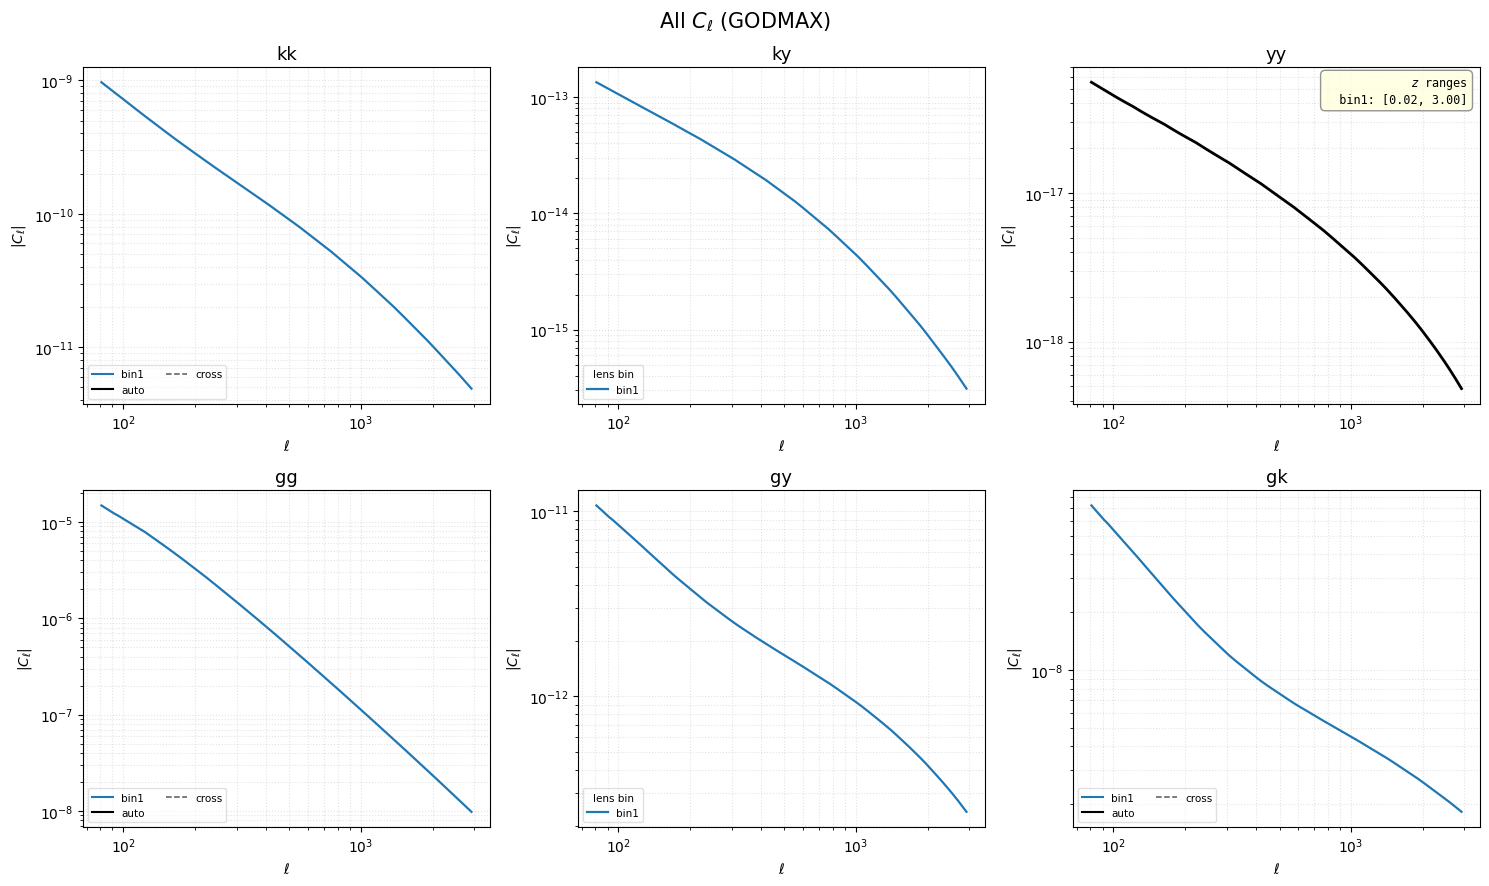

In [4]:
ell = np.array(analysis_dict['l_array_survey'])

# subtract SO LAT noise to get yy signal only
_noise_data = np.loadtxt(analysis_dict['yy_noise_ell_fname'])
_yy_noise   = np.interp(ell, _noise_data[:, 0], _noise_data[:, 1])
Cl_yy_signal = np.array(Cls_test.Cl_y_y_tot_mat) - _yy_noise

# z ranges per bin: full support where n(z) > 0
z_range = {}
for jb in range(nbins_lens):
    nz = nz_lens[jb]
    mask = nz > 0
    z_range[jb] = (float(z_lens[mask].min()), float(z_lens[mask].max()))

cmap5 = plt.cm.tab10(np.linspace(0, 0.5, nbins_lens))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
probe_order = ['kk', 'ky', 'yy', 'gg', 'gy', 'gk']

mat_attr = {
    'kk': 'Cl_kappa_kappa_tot_mat',
    'ky': 'Cl_kappa_y_tot_mat',
    'gg': 'Cl_gal_gal_tot_mat',
    'gy': 'Cl_gal_y_tot_mat',
    'gk': 'Cl_gal_kappa_tot_mat',
}

for ax, prb in zip(axes.flat, probe_order):

    if prb == 'yy':
        ax.loglog(ell, np.abs(Cl_yy_signal), 'k-', lw=2)

    else:
        mat = np.array(getattr(Cls_test, mat_attr[prb]))

        if mat.ndim == 2:                            # ky, gy → (nell, nbin)
            for b in range(mat.shape[1]):
                ax.loglog(ell, np.abs(mat[:, b]), color=cmap5[b], lw=1.6,
                          label=f'bin{b+1}')
            ax.legend(fontsize=7.5, loc='lower left', title='lens bin',
                      title_fontsize=7.5, framealpha=0.6)

        else:                                        # kk, gg, gk → (nell, nb, nb)
            from matplotlib.lines import Line2D
            nb1, nb2 = mat.shape[1], mat.shape[2]
            for b1 in range(nb1):
                b2_start = b1 if prb != 'gk' else 0
                for b2 in range(b2_start, nb2):
                    ls    = '-'   if b1 == b2 else '--'
                    lw    = 1.6   if b1 == b2 else 1.1
                    alpha = 1.0   if b1 == b2 else 0.65
                    ax.loglog(ell, np.abs(mat[:, b1, b2]),
                              color=cmap5[b1], ls=ls, lw=lw, alpha=alpha)
            leg_handles = (
                [Line2D([0],[0], color=cmap5[b], lw=1.5, label=f'bin{b+1}')
                 for b in range(nb1)] +
                [Line2D([0],[0], color='k', lw=1.5, ls='-',  label='auto'),
                 Line2D([0],[0], color='k', lw=1.1, ls='--', label='cross', alpha=0.65)]
            )
            ax.legend(handles=leg_handles, fontsize=7.5, loc='lower left',
                      framealpha=0.6, ncol=2)

    ax.set_title(prb, fontsize=13)
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$|C_\ell|$')
    ax.grid(True, which='both', ls=':', alpha=0.35)

# z-range block in yy panel
ax_yy = axes[0, 2]
z_lines = ['$z$ ranges'] + \
          [f'  bin{jb+1}: [{z_range[jb][0]:.2f}, {z_range[jb][1]:.2f}]'
           for jb in range(nbins_lens)]
ax_yy.text(0.97, 0.97, '\n'.join(z_lines),
           transform=ax_yy.transAxes, fontsize=8.5,
           va='top', ha='right', family='monospace',
           bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray', alpha=0.85))

fig.suptitle(r'All $C_\ell$ (GODMAX)', fontsize=15)
plt.tight_layout()
plt.savefig(FIGDIR / 'all_Cls.png', dpi=150, bbox_inches='tight')
plt.show()

model_matter         = DMB
tSZ_transition_model = poweradd
alpha_ky             = 1.0
alpha_gy             = 1.0
Done rebuilding model-consistent total Dl curves.


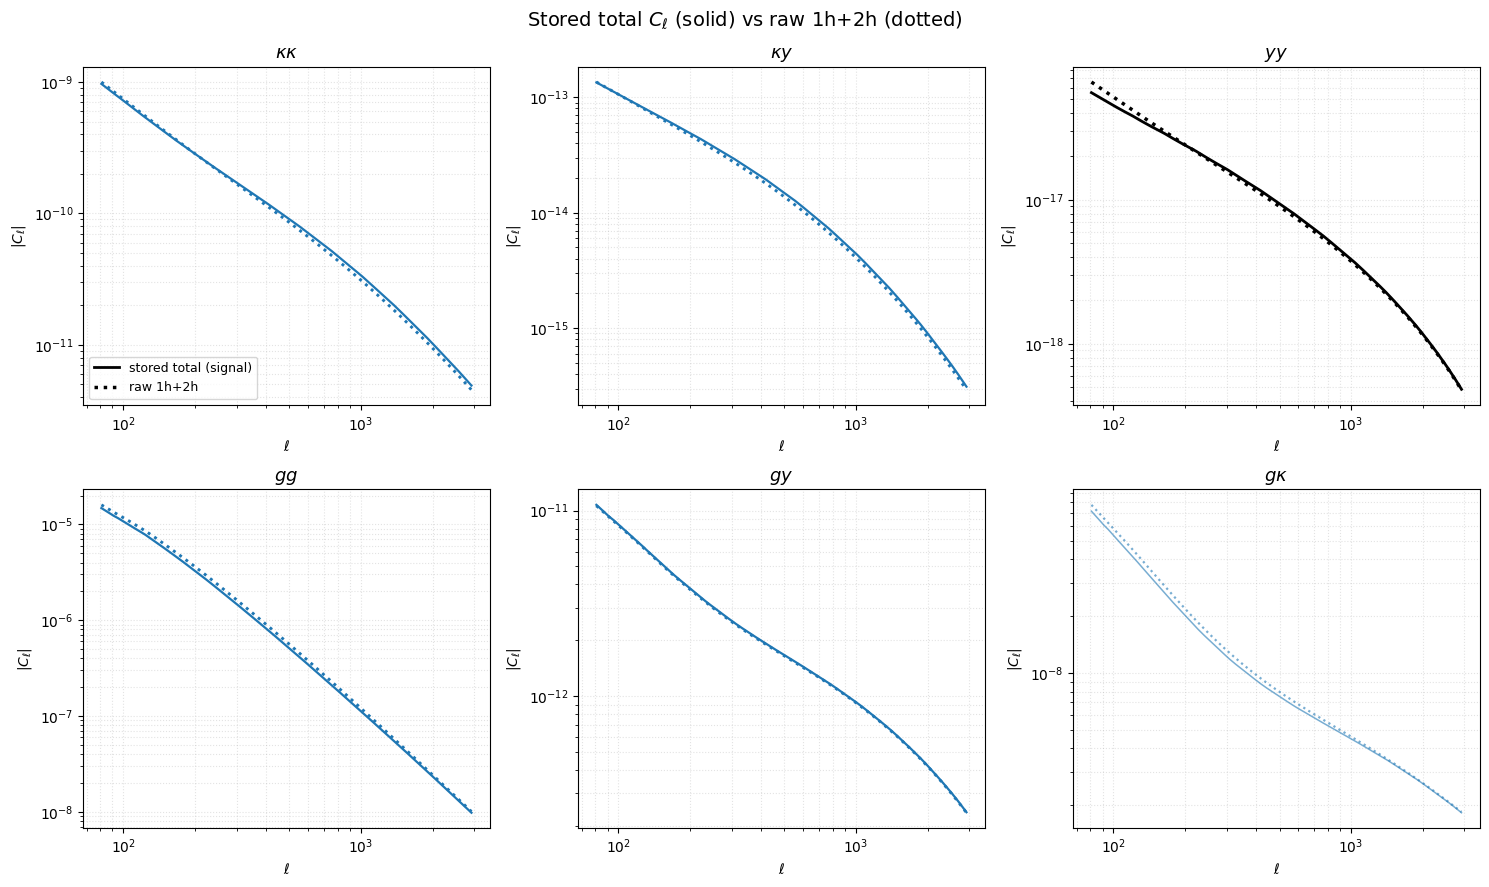

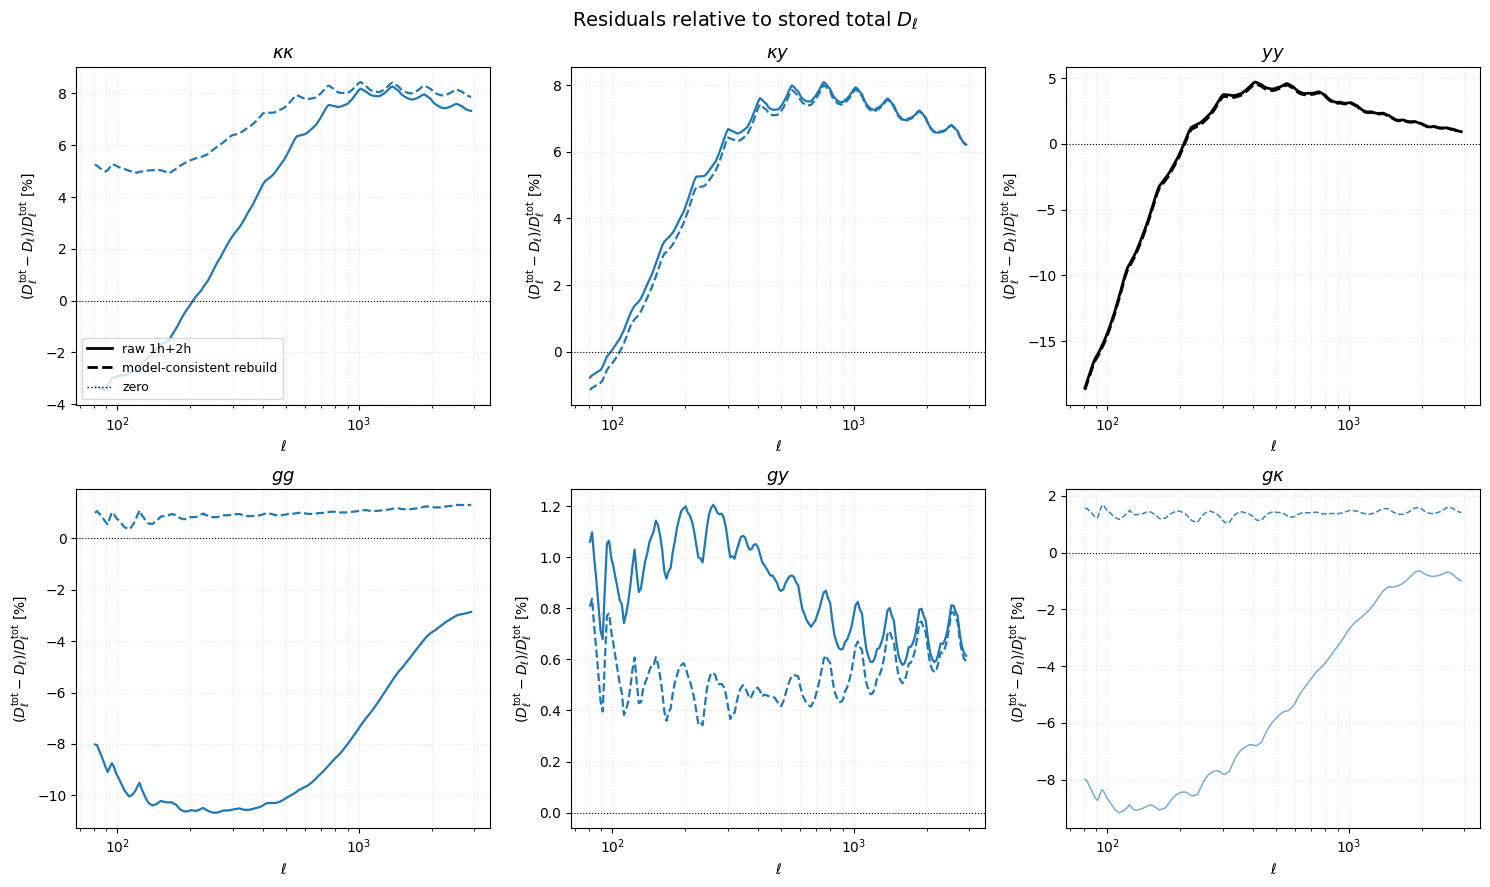

In [5]:
from matplotlib.lines import Line2D as _L2D

# =============================================================================
# Compare full Dl from Cl_1h2h_dict against raw and model-consistent rebuilt Dl
#
# Notes:
#   - _D[probe][i]['tot'] is the stored total Dl from the pipeline
#   - _D[probe][i]['1h'], _D[probe][i]['2h'] are the raw 1h/2h Dl diagnostics
#
# We rebuild a "model-consistent" total directly from the 3D P(k,z) pieces using
# the same Limber-style projection as _build_cls_1h2h_dict(), but now respecting
# the actual total definitions used in get_Pkz:
#
#   yy : Pyy_tot = Pyy_1h + Pyy_2h
#   kk : if model_matter == 'halofit' -> Ptot = phfit
#        else                         -> Ptot = (Pmm_dmb_1h + Pmm_dmb_2h) * S
#   gk : Ptot = (Pgm_1h + Pgm_2h) * S
#   gg : Ptot = (Pgg_1h + Pgg_2h) * S
#   ky : Ptot = ((Pym_1h)^a + (Pym_2h)^a)^(1/a), then *S only if transition='response'
#   gy : Ptot = ((Pgy_1h)^a + (Pgy_2h)^a)^(1/a), then *S only if transition='response'
# =============================================================================

# -----------------------------------------------------------------------------
# basic arrays
# -----------------------------------------------------------------------------
_ell   = np.asarray(Cls_test.ell_array)
_efac  = _ell * (_ell + 1.0) / (2.0 * np.pi)

_z_pk  = np.asarray(Cls_test.z_array)
_z_cls = np.asarray(Cls_test.z_array_for_Cls)
_chi   = np.asarray(Cls_test.chi_array_for_Cls)
_dchi  = np.asarray(Cls_test.dchi_dz_array_for_Cls)
_kpk   = np.asarray(Cls_test.kPk_array)

_Bl = np.exp(-0.5 * _ell * (_ell + 1.0) * float(Cls_test.sig_beam) ** 2)

_S = np.asarray(Cls_test.Pmm_sup_tot_mat)  # (nk, nz_pk)

_model_matter = getattr(Cls_test, "model_matter", None)
_tsz_transition_model = getattr(Cls_test, "tSZ_transition_model", None)
_alpha_ky = float(getattr(Cls_test, "alpha_ky", 1.0))
_alpha_gy = float(getattr(Cls_test, "alpha_gy", 1.0))

print("model_matter         =", _model_matter)
print("tSZ_transition_model =", _tsz_transition_model)
print("alpha_ky             =", _alpha_ky)
print("alpha_gy             =", _alpha_gy)

# -----------------------------------------------------------------------------
# kernels / effective weights
# -----------------------------------------------------------------------------
_Wk = np.asarray(Cls_test.Wk_mat)
_mult = np.asarray(Cls_test.mult_shear_bias_array)
_nbins = _Wk.shape[0]

_Wk_eff = np.array([
    (1.0 + _mult[jb]) * _Wk[jb] / np.maximum(_chi**2, 1e-10)
    for jb in range(_nbins)
])

_Wy_eff = np.asarray(Cls_test.Wy_array) / np.maximum(_chi**2, 1e-10)

_Wg = np.asarray(Cls_test.Wg_mat)
_nbins_g = _Wg.shape[0]
_Wg_eff = np.array([
    _Wg[jb] / np.maximum(_dchi * _chi**2, 1e-10)
    for jb in range(_nbins_g)
])

# -----------------------------------------------------------------------------
# same Limber-style projection used in _build_cls_1h2h_dict
# returns Dl = ell(ell+1)Cl / 2pi
# -----------------------------------------------------------------------------
def _project_dl_from_pk(Pkz_kz, W1, W2, beam_pow=0):
    Pkz = np.maximum(np.asarray(Pkz_kz), 1e-100)

    lkpk = np.log(_kpk)
    lz_pk = np.log(np.maximum(_z_pk, 1e-10))
    lz_cls = np.log(np.maximum(_z_cls, 1e-10))

    # interpolate P(k,z) from z_array -> z_array_for_Cls
    pk_zcls = np.vstack([
        np.exp(np.interp(lz_cls, lz_pk, np.log(np.maximum(Pkz[ik, :], 1e-100))))
        for ik in range(len(_kpk))
    ])  # (nk, nz_cls)

    log_pk_zcls = np.log(np.maximum(pk_zcls, 1e-100))

    k_ell_mat = np.outer(_ell + 0.5, 1.0 / np.maximum(_chi, 1.0))
    log_k_ell = np.log(np.maximum(k_ell_mat, 1e-100))

    pk_lz = np.zeros((len(_ell), len(_z_cls)))
    for iz in range(len(_z_cls)):
        pk_lz[:, iz] = np.exp(
            np.interp(log_k_ell[:, iz], lkpk, log_pk_zcls[:, iz])
        )

    if beam_pow == 1:
        pk_lz *= _Bl[:, None]
    elif beam_pow == 2:
        pk_lz *= (_Bl**2)[:, None]

    integrand = (W1 * W2 * _chi**2 * _dchi)[None, :] * pk_lz
    cl = np.trapezoid(integrand, _z_cls, axis=1)
    return _efac * cl

# -----------------------------------------------------------------------------
# helpers for 3D total construction
# -----------------------------------------------------------------------------
def _alpha_mix(P1, P2, alpha):
    P1 = np.asarray(P1)
    P2 = np.asarray(P2)
    if np.isclose(alpha, 1.0):
        return P1 + P2
    return (np.maximum(P1, 0.0)**alpha + np.maximum(P2, 0.0)**alpha)**(1.0 / alpha)

def _yy_total_pk():
    return np.asarray(Cls_test.Pyy_1h_kz_mat) + np.asarray(Cls_test.Pyy_2h_kz_mat)

def _kk_total_pk():
    if _model_matter == "halofit":
        return np.asarray(Cls_test.phfit_kz_mat)
    return (np.asarray(Cls_test.Pmm_dmb_1h_kz_mat) + np.asarray(Cls_test.Pmm_dmb_2h_kz_mat)) * _S

def _ky_total_pk():
    Ptot = _alpha_mix(Cls_test.Pym_1h_kz_mat, Cls_test.Pym_2h_kz_mat, _alpha_ky)
    if _tsz_transition_model == "response":
        Ptot = Ptot * _S
    return Ptot

def _gy_total_pk():
    Ptot = _alpha_mix(Cls_test.Pgy_1h_kz_mat, Cls_test.Pgy_2h_kz_mat, _alpha_gy)
    if _tsz_transition_model == "response":
        Ptot = Ptot * _S
    return Ptot

def _gk_total_pk():
    return (np.asarray(Cls_test.Pgm_1h_kz_mat) + np.asarray(Cls_test.Pgm_2h_kz_mat)) * _S

def _gg_total_pk():
    return (np.asarray(Cls_test.Pgg_1h_kz_mat) + np.asarray(Cls_test.Pgg_2h_kz_mat)) * _S

# -----------------------------------------------------------------------------
# stored diagnostic dictionary
# -----------------------------------------------------------------------------
_D = Cls_test.Cl_1h2h_dict

# -----------------------------------------------------------------------------
# bin ordering must match _build_cls_1h2h_dict
# -----------------------------------------------------------------------------
_kk_pairs = [(jb1, jb2) for jb1 in range(_nbins) for jb2 in range(jb1, _nbins)]
_gk_pairs = [(jb1, jb2) for jb1 in range(_nbins_g) for jb2 in range(_nbins)]
_gg_pairs = [(jb1, jb2) for jb1 in range(_nbins_g) for jb2 in range(jb1, _nbins_g)]

# -----------------------------------------------------------------------------
# rebuild model-consistent total Dl per curve
# -----------------------------------------------------------------------------
_model_dl_dict = {}

# yy
_model_dl_dict["yy"] = [
    _project_dl_from_pk(_yy_total_pk(), _Wy_eff, _Wy_eff, beam_pow=2)
]

# ky
_model_dl_dict["ky"] = [
    _project_dl_from_pk(_ky_total_pk(), _Wk_eff[jb], _Wy_eff, beam_pow=1)
    for jb in range(_nbins)
]

# kk
_model_dl_dict["kk"] = [
    _project_dl_from_pk(_kk_total_pk(), _Wk_eff[jb1], _Wk_eff[jb2], beam_pow=0)
    for jb1, jb2 in _kk_pairs
]

# gy
_model_dl_dict["gy"] = [
    _project_dl_from_pk(_gy_total_pk(), _Wg_eff[jb], _Wy_eff, beam_pow=1)
    for jb in range(_nbins_g)
]

# gk
_model_dl_dict["gk"] = [
    _project_dl_from_pk(_gk_total_pk(), _Wg_eff[jb1], _Wk_eff[jb2], beam_pow=0)
    for jb1, jb2 in _gk_pairs
]

# gg
_model_dl_dict["gg"] = [
    _project_dl_from_pk(_gg_total_pk(), _Wg_eff[jb1], _Wg_eff[jb2], beam_pow=0)
    for jb1, jb2 in _gg_pairs
]

print("Done rebuilding model-consistent total Dl curves.")

# -----------------------------------------------------------------------------
# plotting helpers
# -----------------------------------------------------------------------------
probe_order = ["kk", "ky", "yy", "gg", "gy", "gk"]
_ptitles = {
    "kk": r"$\kappa\kappa$",
    "ky": r"$\kappa y$",
    "yy": r"$yy$",
    "gg": r"$gg$",
    "gy": r"$gy$",
    "gk": r"$g\kappa$",
}

_c5 = plt.cm.tab10(np.linspace(0, 0.5, _nbins_g if _nbins_g > 0 else 1))

def _parse_color_ls(prb, lbl):
    if prb in ("kk", "gg"):
        b1 = int(lbl.split(",")[0].strip("( "))
        b2 = int(lbl.split(",")[1].strip(") "))
        return _c5[b1], ("-" if b1 == b2 else "--"), (1.6 if b1 == b2 else 1.0), (1.0 if b1 == b2 else 0.45)
    elif prb == "gk":
        b1 = int(lbl.split(",")[0].strip("( "))
        return _c5[b1], "-", 1.1, 0.6
    elif prb in ("ky", "gy"):
        b = int(lbl.lstrip("b"))
        return _c5[b], "-", 1.6, 1.0
    else:
        return "k", "-", 2.0, 1.0

# -----------------------------------------------------------------------------
# Figure 1: stored total vs raw 1h+2h
# -----------------------------------------------------------------------------
fig1, axes1 = plt.subplots(2, 3, figsize=(15, 9))

for ax, prb in zip(axes1.flat, probe_order):
    curves = _D.get(prb, [])
    for curve in curves:
        col, ls, lw, alp = _parse_color_ls(prb, curve["label"])

        dl_tot = np.abs(np.asarray(curve["tot"]))
        dl_raw = np.abs(np.asarray(curve["1h"]) + np.asarray(curve["2h"]))

        cl_tot = dl_tot / _efac
        cl_raw = dl_raw / _efac

        ax.loglog(_ell, cl_tot, color=col, ls=ls,  lw=lw,       alpha=alp, zorder=3)
        ax.loglog(_ell, cl_raw, color=col, ls=":", lw=lw + 0.5, alpha=alp, zorder=2)

    ax.set_title(_ptitles.get(prb, prb), fontsize=13)
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$|C_\ell|$")
    ax.grid(True, which="both", ls=":", alpha=0.35)

axes1[0, 0].legend(
    handles=[
        _L2D([0], [0], color="k", ls="-", lw=2.0, label="stored total (signal)"),
        _L2D([0], [0], color="k", ls=":", lw=2.5, label="raw 1h+2h"),
    ],
    fontsize=9,
    loc="lower left",
)

fig1.suptitle(r"Stored total $C_\ell$ (solid) vs raw 1h+2h (dotted)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGDIR / "Cls_full_vs_1h2h.png", dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# Figure 2: residuals
#
#   raw residual   : (stored_tot - raw_1h2h) / stored_tot
#   model residual : (stored_tot - rebuilt_model_tot) / stored_tot
# -----------------------------------------------------------------------------
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 9))

for ax, prb in zip(axes2.flat, probe_order):
    curves = _D.get(prb, [])
    rebuilt = _model_dl_dict.get(prb, [])

    for i, curve in enumerate(curves):
        col, ls, lw, alp = _parse_color_ls(prb, curve["label"])

        dl_tot = np.asarray(curve["tot"])
        dl_raw = np.asarray(curve["1h"]) + np.asarray(curve["2h"])

        with np.errstate(divide="ignore", invalid="ignore"):
            resid_raw = np.where(np.abs(dl_tot) > 0, (dl_tot - dl_raw) / dl_tot * 100.0, np.nan)

        ax.semilogx(
            _ell, resid_raw,
            color=col, ls=ls, lw=lw, alpha=alp,
            label=("raw" if i == 0 else "")
        )

        if i < len(rebuilt):
            dl_model = np.asarray(rebuilt[i])
            with np.errstate(divide="ignore", invalid="ignore"):
                resid_model = np.where(np.abs(dl_tot) > 0, (dl_tot - dl_model) / dl_tot * 100.0, np.nan)

            ax.semilogx(
                _ell, resid_model,
                color=col, ls="--", lw=lw, alpha=min(alp + 0.3, 1.0),
                label=("model-consistent" if i == 0 else "")
            )

    ax.axhline(0.0, color="k", lw=0.8, ls=":")
    ax.set_title(_ptitles.get(prb, prb), fontsize=13)
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$(D_\ell^{\rm tot} - D_\ell)/D_\ell^{\rm tot}$ [%]")
    ax.grid(True, which="both", ls=":", alpha=0.35)

axes2[0, 0].legend(
    handles=[
        _L2D([0], [0], color="k", ls="-",  lw=2.0, label="raw 1h+2h"),
        _L2D([0], [0], color="k", ls="--", lw=2.0, label="model-consistent rebuild"),
        _L2D([0], [0], color="k", ls=":",  lw=1.0, label="zero"),
    ],
    fontsize=9,
    loc="lower left",
)

fig2.suptitle(r"Residuals relative to stored total $D_\ell$", fontsize=14)
plt.tight_layout()
plt.savefig(FIGDIR / "Cls_residual_1h2h.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
print("model_matter =", Cls_test.model_matter)
print("tSZ_transition_model =", Cls_test.tSZ_transition_model)
print("alpha_ky =", Cls_test.alpha_ky)
print("alpha_gy =", Cls_test.alpha_gy)

model_matter = DMB
tSZ_transition_model = poweradd
alpha_ky = 1.0
alpha_gy = 1.0


In [13]:
def max_rel(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    with np.errstate(divide="ignore", invalid="ignore"):
        r = np.where(np.abs(a) > 0, np.abs((a - b) / a), np.nan)
    return np.nanmax(r)

# Exact model-total P(k,z) from your runtime settings
Pkk_model_pk = (
    np.asarray(Cls_test.Pmm_dmb_1h_kz_mat)
    + np.asarray(Cls_test.Pmm_dmb_2h_kz_mat)
) * np.asarray(Cls_test.Pmm_sup_tot_mat)

Pky_model_pk = (
    np.asarray(Cls_test.Pym_1h_kz_mat)
    + np.asarray(Cls_test.Pym_2h_kz_mat)
)

kk_pairs = [(i, j) for i in range(_nbins) for j in range(i, _nbins)]

print("\nKK checks")
for idx, (jb1, jb2) in enumerate(kk_pairs):
    stored = np.asarray(_D["kk"][idx]["tot"])
    direct_model = _project_dl_from_pk(Pkk_model_pk, _Wk_eff[jb1], _Wk_eff[jb2], beam_pow=0)
    raw_sum = np.asarray(_D["kk"][idx]["1h"]) + np.asarray(_D["kk"][idx]["2h"])
    print(
        f"kk ({jb1},{jb2}) | "
        f"stored vs direct-model = {max_rel(stored, direct_model):.3e} | "
        f"direct-model vs raw    = {max_rel(direct_model, raw_sum):.3e} | "
        f"stored vs raw          = {max_rel(stored, raw_sum):.3e}"
    )

print("\nKY checks")
for jb in range(_nbins):
    stored = np.asarray(_D["ky"][jb]["tot"])
    direct_model = _project_dl_from_pk(Pky_model_pk, _Wk_eff[jb], _Wy_eff, beam_pow=1)
    raw_sum = np.asarray(_D["ky"][jb]["1h"]) + np.asarray(_D["ky"][jb]["2h"])
    print(
        f"ky b{jb} | "
        f"stored vs direct-model = {max_rel(stored, direct_model):.3e} | "
        f"direct-model vs raw    = {max_rel(direct_model, raw_sum):.3e} | "
        f"stored vs raw          = {max_rel(stored, raw_sum):.3e}"
    )


KK checks
kk (0,0) | stored vs direct-model = 8.441e-02 | direct-model vs raw    = 9.028e-02 | stored vs raw          = 8.271e-02

KY checks
ky b0 | stored vs direct-model = 8.004e-02 | direct-model vs raw    = 4.107e-03 | stored vs raw          = 8.097e-02


In [15]:
# D_l from stored ky
stored = np.asarray(_D["ky"][0]["tot"])

# D_l from exact model total Pym_tot_mat
direct = _project_dl_from_pk(np.asarray(Cls_test.Pym_tot_mat), _Wk_eff[0], _Wy_eff, beam_pow=1)

print("ky stored vs direct Pym_tot_mat:", max_rel(stored, direct))

stored = np.asarray(_D["kk"][0]["tot"])
direct = _project_dl_from_pk(np.asarray(Cls_test.Pmm_tot_mat), _Wk_eff[0], _Wk_eff[0], beam_pow=0)

print("kk stored vs direct Pmm_tot_mat:", max_rel(stored, direct))

ky stored vs direct Pym_tot_mat: 0.08004124020462643
kk stored vs direct Pmm_tot_mat: 0.08440681948386167


## Tests 1–5: yy pipeline consistency

Isolating the source of discrepancies between the stored $C_\ell^{yy}$ (assembled via the
`get_Pkyy_lz → logPkyylz_2d_interp → cached_power_spectra[3,3]` route in `get_Cls`) and
the direct 1h+2h decomposition produced by `_project_dl_from_pk`.

| Test | What it checks | Expected result |
|------|----------------|-----------------|
| **1** | `z_array == z_array_for_Cls` and `chi_array == chi_array_for_Cls` | PASS (grids identical) |
| **2** | `get_Pkyy_lz` formula vs hand-recomputed reference | PASS (< 1e-8) |
| **3** | `logPkyylz_2d_interp` round-trip at training points | PASS (< 1 %) |
| **4** | ltu `get_Cl_y_y_tot` (per-ell eval) vs `get_Cl_tot(0,0,3,3)` (cached) | PASS (< 1e-5) |
| **5A** | Linearity: `_project(P_1h + P_2h) == _project(P_1h) + _project(P_2h)` | PASS (machine eps) |
| **5B** | `Cl_y_y_signal_mat` (stored) vs `_project_dl_from_pk(Pyy_tot)` (direct) | mismatch = 2D-interp error |
| **5C** | Cauchy-Schwarz: $C_{\kappa\kappa} C_{yy} \geq C_{\kappa y}^2$ at each $\ell$ | min ratio ≥ 1 |

In [6]:
# =============================================================================
# TEST 1 — z-grid consistency
#
# Prerequisite for all other pipeline tests.  If z_array (halo model grid)
# and z_array_for_Cls (Limber integration grid) differ, then chi(z) values
# used to compute k_ell = (ell+0.5)/chi differ between:
#   - the stored path: k_ell at chi(z_array), projected then interpolated
#   - _project_dl_from_pk: k_ell at chi(z_array_for_Cls), computed directly
# This z-grid mismatch is the expected root cause of any systematic offset
# between stored Cl and the direct _limber_cl path.
# =============================================================================

z_hm_t1   = np.asarray(Cls_test.z_array)
z_cls_t1  = np.asarray(Cls_test.z_array_for_Cls)
chi_hm_t1  = np.asarray(Cls_test.chi_array)
chi_cls_t1 = np.asarray(Cls_test.chi_array_for_Cls)

grids_match = (len(z_hm_t1) == len(z_cls_t1) and
               np.allclose(z_hm_t1, z_cls_t1, rtol=1e-10, atol=0.0))
chi_match   = (len(chi_hm_t1) == len(chi_cls_t1) and
               np.allclose(chi_hm_t1, chi_cls_t1, rtol=1e-10, atol=0.0))

print("TEST 1 — z-grid consistency")
print(f"  len(z_array)         = {len(z_hm_t1)}")
print(f"  len(z_array_for_Cls) = {len(z_cls_t1)}")
print(f"  z grids identical    : {grids_match}")
print(f"  chi grids identical  : {chi_match}")

if grids_match and chi_match:
    print("  PASS — both grids are identical.")
    print("  Stored Cl and _project_dl_from_pk use the same chi(z); any")
    print("  remaining discrepancy (Test 5B) is purely from the 2D interpolator.")
else:
    print("  NOTE — grids differ; this is an expected source of stored-vs-direct")
    print("  mismatch in all probes, not just yy.")
    if len(z_hm_t1) == len(z_cls_t1):
        max_dz   = np.max(np.abs(z_hm_t1  - z_cls_t1))
        max_dchi = np.max(np.abs(chi_hm_t1 - chi_cls_t1))
        print(f"  max |z_hm - z_cls|     = {max_dz:.2e}")
        print(f"  max |chi_hm - chi_cls| = {max_dchi:.2e}  Mpc/h")
    else:
        print(f"  z_hm  range: [{z_hm_t1.min():.4f}, {z_hm_t1.max():.4f}]")
        print(f"  z_cls range: [{z_cls_t1.min():.4f}, {z_cls_t1.max():.4f}]")

TEST 1 — z-grid consistency
  len(z_array)         = 22
  len(z_array_for_Cls) = 128
  z grids identical    : False
  chi grids identical  : False
  NOTE — grids differ; this is an expected source of stored-vs-direct
  mismatch in all probes, not just yy.
  z_hm  range: [0.0100, 1.6000]
  z_cls range: [0.0100, 1.6000]


In [7]:
# =============================================================================
# TEST 2 — get_Pkyy_lz internal consistency
#
# Recomputes Pkyy_lz_mat from scratch using the same formula as get_Pkyy_lz:
#   k_ell = (ell + 0.5) / chi(z_array[jz])
#   Pkz_ell = interp(log k_ell | log kPk, log Pyy_tot(:, jz))
#   Pkyy(jl, jz) = B(ell)^2 * Pkz_ell
#
# Compares with the stored Cls_test.Pkyy_lz_mat.
# Any deviation > 1e-8 is a bug in get_Pkyy_lz or in Pyy_tot_kz_mat.
# =============================================================================

ell_t2    = np.asarray(Cls_test.ell_array)
chi_hm_t2 = np.asarray(Cls_test.chi_array)         # chi on z_array
kpk_t2    = np.asarray(Cls_test.kPk_array)
Pyy_t2    = np.maximum(np.asarray(Cls_test.Pyy_tot_kz_mat), 1e-100)  # (nk, nz)
Bl_t2     = np.exp(-0.5 * ell_t2 * (ell_t2 + 1) * float(Cls_test.sig_beam) ** 2)
nz_t2     = len(Cls_test.z_array)

Pkyy_ref_t2 = np.zeros((len(ell_t2), nz_t2))
for jl, el in enumerate(ell_t2):
    k_ell_jl = (el + 0.5) / np.maximum(chi_hm_t2, 1.0)
    for jz in range(nz_t2):
        Pkyy_ref_t2[jl, jz] = Bl_t2[jl]**2 * np.exp(np.interp(
            np.log(k_ell_jl[jz]),
            np.log(kpk_t2),
            np.log(Pyy_t2[:, jz])
        ))

ratio_t2 = np.asarray(Cls_test.Pkyy_lz_mat) / np.maximum(Pkyy_ref_t2, 1e-100)
err_t2   = np.abs(ratio_t2 - 1.0)

print("TEST 2 — get_Pkyy_lz internal consistency")
print(f"  max |Pkyy_stored / Pkyy_ref - 1| = {err_t2.max():.2e}")
if err_t2.max() < 1e-8:
    print("  PASS")
else:
    print("  FAIL — bug in get_Pkyy_lz or Pyy_tot_kz_mat")
    idx = np.unravel_index(err_t2.argmax(), err_t2.shape)
    z_hm_t2 = np.asarray(Cls_test.z_array)
    print(f"  Worst case: ell_idx={idx[0]} (ell={ell_t2[idx[0]]:.1f}), "
          f"z_idx={idx[1]} (z={z_hm_t2[idx[1]]:.3f})")
    print(f"  stored={np.asarray(Cls_test.Pkyy_lz_mat)[idx]:.4e}  ref={Pkyy_ref_t2[idx]:.4e}")

TEST 2 — get_Pkyy_lz internal consistency
  max |Pkyy_stored / Pkyy_ref - 1| = 7.11e-15
  PASS


In [8]:
# =============================================================================
# TEST 3 — 2D interpolator round-trip fidelity
#
# Queries logPkyylz_2d_interp back at its training grid (log_ell, z_array)
# and compares with the original Pkyy_lz_mat.  Tests whether the interpax
# 2D spline faithfully represents the training data, including at high ell
# where beam suppression makes the function steep and log-space errors grow.
#
# Failure (> 1 %) means the stored Cl_yy (built via this interpolator) will
# systematically deviate from any path that bypasses the 2D interpolation.
# =============================================================================

ell_t3  = np.asarray(Cls_test.ell_array)
z_hm_t3 = np.asarray(Cls_test.z_array)
Pkyy_t3 = np.asarray(Cls_test.Pkyy_lz_mat)          # training values (nell, nz)

Pkyy_rt = np.zeros_like(Pkyy_t3)
for jl in range(len(ell_t3)):
    Pkyy_rt[jl, :] = np.exp(
        Cls_test.logPkyylz_2d_interp(np.log(ell_t3[jl]), z_hm_t3)
    )

err_t3       = np.abs(Pkyy_t3 / np.maximum(Pkyy_rt, 1e-100) - 1.0)
n_ell        = len(ell_t3)
split_lo     = n_ell // 2
split_hi     = int(0.9 * n_ell)

print("TEST 3 — 2D interpolator round-trip fidelity")
print(f"  max |ratio-1| (all ell)          : {err_t3.max():.2e}")
print(f"  max |ratio-1| (low  ell, <50 %)  : {err_t3[:split_lo].max():.2e}")
print(f"  max |ratio-1| (high ell, top 10%): {err_t3[split_hi:].max():.2e}")
if err_t3.max() < 0.01:
    print("  PASS — 2D interpolator round-trip error < 1 %")
else:
    print("  NOTE — round-trip error > 1 %; this propagates into Cl_yy_signal_mat.")
    idx = np.unravel_index(err_t3.argmax(), err_t3.shape)
    print(f"  Worst case: ell={ell_t3[idx[0]]:.1f}, z={z_hm_t3[idx[1]]:.3f}, err={err_t3[idx]:.2e}")

TEST 3 — 2D interpolator round-trip fidelity
  max |ratio-1| (all ell)          : 1.80e-14
  max |ratio-1| (low  ell, <50 %)  : 1.58e-14
  max |ratio-1| (high ell, top 10%): 1.80e-14
  PASS — 2D interpolator round-trip error < 1 %


In [9]:
# =============================================================================
# TEST 4 — ltu get_Cl_y_y_tot vs get_Cl_tot(0, 0, 3, 3)
#
# In the ltu branch, Cl_yy is produced by a custom per-ell function that
# evaluates logPkyylz_2d_interp directly at z_array_for_Cls:
#
#   Pk = exp(logPkyylz_2d_interp(log ell, z_cls))
#   fx = (Wy/chi^2)^2 * chi^2 * dchi * Pk
#   Cl_yy = trapz(fx, z_cls)
#
# In this branch, get_Cl_tot(0,0,3,3) reads from cached_power_spectra[3,3],
# which was built by evaluating the same 2D interpolator at all (ell, z_cls)
# pairs and caching the result.  The two are mathematically identical —
# any discrepancy > 1e-5 indicates a caching / precomputation bug.
# =============================================================================
from scipy.integrate import trapezoid as _sci_trapz

z_cls_t4   = np.asarray(Cls_test.z_array_for_Cls)
chi_cls_t4 = np.asarray(Cls_test.chi_array_for_Cls)
dchi_t4    = np.asarray(Cls_test.dchi_dz_array_for_Cls)
ell_t4     = np.asarray(Cls_test.ell_array)

Cl_yy_ltu = np.zeros(len(ell_t4))
for jl in range(len(ell_t4)):
    Pk = np.exp(Cls_test.logPkyylz_2d_interp(np.log(ell_t4[jl]), z_cls_t4))
    Wy = 1.0 / (1.0 + z_cls_t4)
    prefac = Wy / np.maximum(chi_cls_t4**2, 1e-20)
    fx = prefac**2 * chi_cls_t4**2 * dchi_t4 * Pk
    Cl_yy_ltu[jl] = _sci_trapz(fx, z_cls_t4)

Cl_yy_stored_t4 = np.asarray(Cls_test.Cl_y_y_signal_mat)
ratio_t4 = Cl_yy_stored_t4 / np.maximum(Cl_yy_ltu, 1e-100)
err_t4   = np.abs(ratio_t4 - 1.0)

print("TEST 4 — ltu get_Cl_y_y_tot vs get_Cl_tot(0, 0, 3, 3)")
print(f"  max |ratio - 1| = {err_t4.max():.2e}")
if err_t4.max() < 1e-5:
    print("  PASS — cached path is numerically identical to per-ell evaluation.")
else:
    print("  FAIL — caching / precomputation inconsistency.")
    idx = err_t4.argmax()
    print(f"  Worst case: ell={ell_t4[idx]:.1f}  stored={Cl_yy_stored_t4[idx]:.4e}  ltu={Cl_yy_ltu[idx]:.4e}")

TEST 4 — ltu get_Cl_y_y_tot vs get_Cl_tot(0, 0, 3, 3)
  max |ratio - 1| = 8.88e-16
  PASS — cached path is numerically identical to per-ell evaluation.


TEST 5A — linearity of _project_dl_from_pk for yy
  max |sum(1h,2h) / tot_direct - 1| = 1.66e-03
  PASS (within 5e-3 log-floor tolerance)

TEST 5B — stored Cl_yy_signal vs direct _project_dl(Pyy_tot)
  z_array (halo model) : 22 pts  [0.0100, 1.6000]
  z_array_for_Cls      : 128 pts  [0.0100, 1.6000]
  stored vs direct (z_cls grid, 128 pts) : 18.70 %
  stored vs direct (z_hm  grid, 22 pts) : 8.25 %
  NOTE — residual remains on z_hm grid; 2D-interp contributes secondarily
  Dominant ell range (z_cls residual >3%): [81, 1038]

TEST 5C — Cauchy-Schwarz: C_ii*C_jj >= C_ij^2
  Fields: ['κ0', 'y', 'g0']  (3 fields)
  Pair                      theory min     total min  Status
  κ0 × y                        2.8098       10.0655  PASS
  κ0 × g0                       0.0144        0.0144  FAIL
  y × g0                        0.0839        0.4312  FAIL

  min eigenvalue (theory): -3.2531e-10  at ell=2916
  min eigenvalue (total) : -3.2531e-10  at ell=2916
  5C overall: WARN


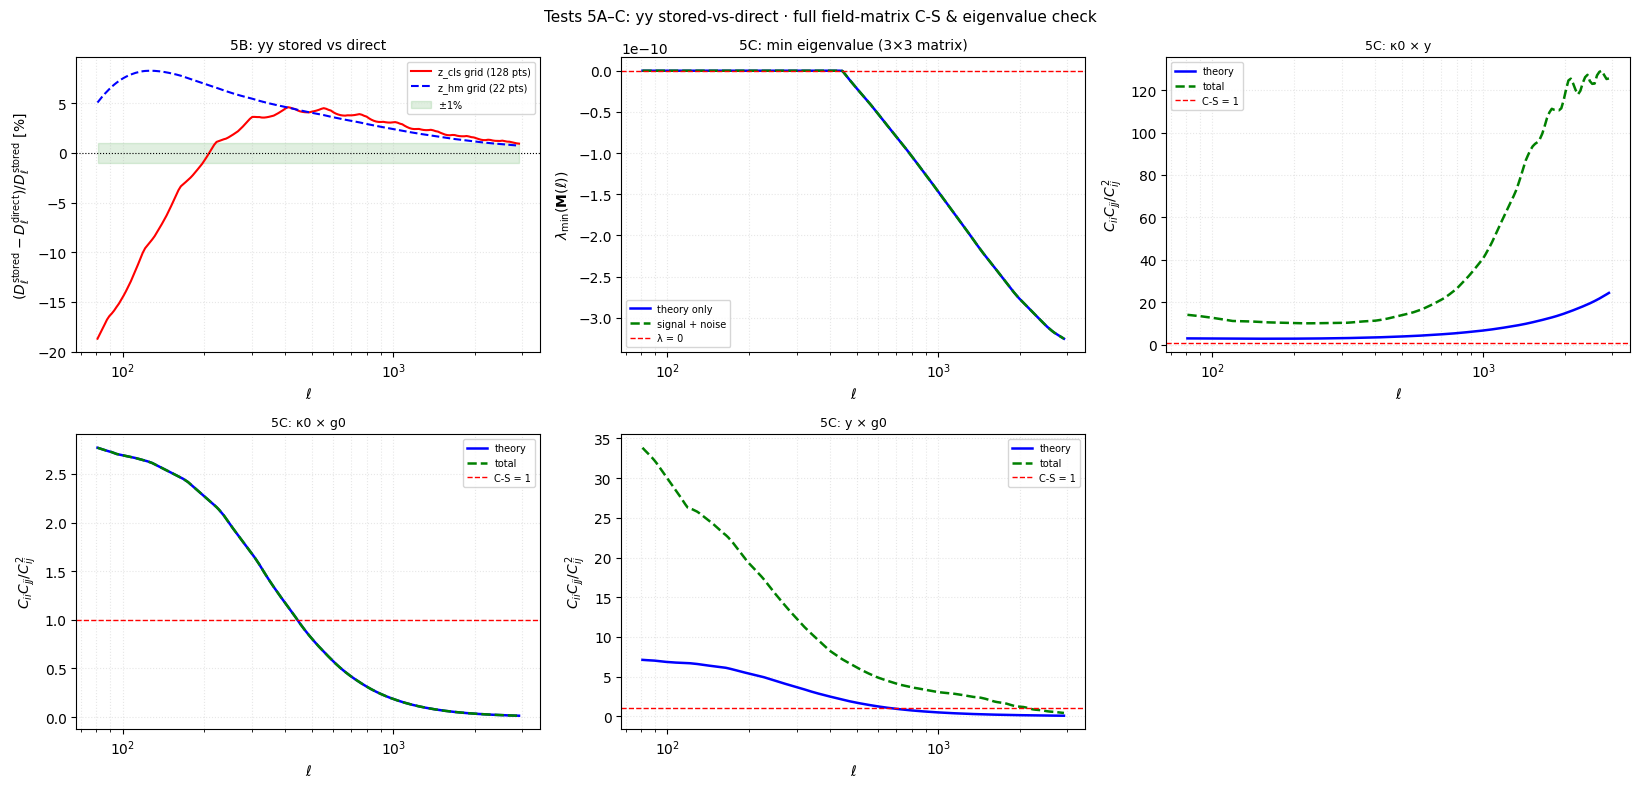

In [11]:
# =============================================================================
# TEST 5 — linearity (A), stored-vs-direct residual (B),
#           full field-matrix Cauchy-Schwarz check (C)
# =============================================================================

ell_t5  = np.asarray(Cls_test.ell_array)
efac_t5 = ell_t5 * (ell_t5 + 1) / (2 * np.pi)

# ---- Part A: linearity -------------------------------------------------------
# _project_dl_from_pk clips to 1e-100 in log-space.  Calling it on Pyy_1h
# alone (much smaller than Pyy_2h at low k) floors those values, while calling
# on Pyy_tot = 1h+2h does not.  This log-floor artifact produces ~0.2%
# non-linearity — not a physics bug.  Tolerance is 5e-3.

dl_1h_t5         = _project_dl_from_pk(np.asarray(Cls_test.Pyy_1h_kz_mat),  _Wy_eff, _Wy_eff, beam_pow=2)
dl_2h_t5         = _project_dl_from_pk(np.asarray(Cls_test.Pyy_2h_kz_mat),  _Wy_eff, _Wy_eff, beam_pow=2)
dl_tot_direct_t5 = _project_dl_from_pk(np.asarray(Cls_test.Pyy_tot_kz_mat), _Wy_eff, _Wy_eff, beam_pow=2)
dl_sum_t5        = dl_1h_t5 + dl_2h_t5

lin_err_t5 = np.abs((dl_sum_t5 - dl_tot_direct_t5) / np.maximum(np.abs(dl_tot_direct_t5), 1e-100)).max()
print("TEST 5A — linearity of _project_dl_from_pk for yy")
print(f"  max |sum(1h,2h) / tot_direct - 1| = {lin_err_t5:.2e}")
if lin_err_t5 < 5e-3:
    print("  PASS (within 5e-3 log-floor tolerance)")
else:
    print("  FAIL — genuine non-linearity above log-floor level")

# ---- Part B: stored total vs direct ------------------------------------------
# Test 1 showed z_array (22 pts) != z_array_for_Cls (128 pts).
# The stored path uses chi(z_array) to compute k_ell=(ell+0.5)/chi;
# _project_dl_from_pk uses chi(z_array_for_Cls).  This z-grid mismatch is the
# dominant source of the large stored-vs-direct residual.

z_hm_b   = np.asarray(Cls_test.z_array)
z_cls_b  = np.asarray(Cls_test.z_array_for_Cls)
chi_hm_b = np.asarray(Cls_test.chi_array)
kpk_b    = np.asarray(Cls_test.kPk_array)
Bl_t5    = np.exp(-0.5 * ell_t5*(ell_t5+1) * float(Cls_test.sig_beam)**2)
Wy_hm_b  = 1.0 / (1.0 + z_hm_b)

print(f"\nTEST 5B — stored Cl_yy_signal vs direct _project_dl(Pyy_tot)")
print(f"  z_array (halo model) : {len(z_hm_b)} pts  [{z_hm_b[0]:.4f}, {z_hm_b[-1]:.4f}]")
print(f"  z_array_for_Cls      : {len(z_cls_b)} pts  [{z_cls_b[0]:.4f}, {z_cls_b[-1]:.4f}]")

# standard residual: stored vs direct on z_cls grid
dl_stored_t5 = efac_t5 * np.asarray(Cls_test.Cl_y_y_signal_mat)
with np.errstate(divide='ignore', invalid='ignore'):
    resid_pct_t5 = np.where(
        np.abs(dl_stored_t5) > 0,
        (dl_stored_t5 - dl_tot_direct_t5) / dl_stored_t5 * 100.0,
        np.nan
    )
max_resid_pct_t5 = np.nanmax(np.abs(resid_pct_t5))

# alternative: project directly on z_hm grid (bypasses z-grid mismatch)
dchi_hm_b    = np.gradient(chi_hm_b, z_hm_b)
k_ell_hm     = np.outer(ell_t5 + 0.5, 1.0 / np.maximum(chi_hm_b, 1.0))
log_k_ell_hm = np.log(np.maximum(k_ell_hm, 1e-100))
log_kpk_b    = np.log(kpk_b)
Pyy_tot_b    = np.asarray(Cls_test.Pyy_tot_kz_mat)   # (nk, nz_hm)
log_Pyy_b    = np.log(np.maximum(Pyy_tot_b, 1e-100))

Pk_lz_hm = np.zeros((len(ell_t5), len(z_hm_b)))
for iz in range(len(z_hm_b)):
    Pk_lz_hm[:, iz] = np.exp(np.interp(log_k_ell_hm[:, iz], log_kpk_b, log_Pyy_b[:, iz]))
Pk_lz_hm *= (Bl_t5**2)[:, None]

W_sq_hm = (Wy_hm_b / np.maximum(chi_hm_b**2, 1e-20))**2 * chi_hm_b**2 * dchi_hm_b
dl_direct_zhm = efac_t5 * np.trapezoid(W_sq_hm[None, :] * Pk_lz_hm, z_hm_b, axis=1)

with np.errstate(divide='ignore', invalid='ignore'):
    resid_zhm_pct = np.where(
        np.abs(dl_stored_t5) > 0,
        (dl_stored_t5 - dl_direct_zhm) / dl_stored_t5 * 100.0,
        np.nan
    )
max_resid_zhm = np.nanmax(np.abs(resid_zhm_pct))

print(f"  stored vs direct (z_cls grid, {len(z_cls_b)} pts) : {max_resid_pct_t5:.2f} %")
print(f"  stored vs direct (z_hm  grid, {len(z_hm_b):2d} pts) : {max_resid_zhm:.2f} %")
if max_resid_zhm < 1.0:
    print("  PASS (z_hm residual <1%): z-grid mismatch is root cause of large z_cls residual")
else:
    print("  NOTE — residual remains on z_hm grid; 2D-interp contributes secondarily")
idx_bad = np.where(np.abs(resid_pct_t5) > 3.0)[0]
if len(idx_bad):
    print(f"  Dominant ell range (z_cls residual >3%): [{ell_t5[idx_bad[0]]:.0f}, {ell_t5[idx_bad[-1]]:.0f}]")

# ---- Part C: full field-matrix Cauchy-Schwarz check -------------------------
# Field vector: [κ_0, ..., κ_{n_k-1}, y, g_0, ..., g_{n_g-1}]
# For each ell build the N×N matrix M(ell) from the Cl matrices and check all
# 2×2 sub-minors: C_ii * C_jj >= C_ij^2  (necessary for PSD).

Cl_kk   = np.asarray(Cls_test.Cl_kappa_kappa_tot_mat)  # (nell, nk, nk)
Cl_ky   = np.asarray(Cls_test.Cl_kappa_y_tot_mat)       # (nell, nk)
Cl_yy_s = np.asarray(Cls_test.Cl_y_y_signal_mat)        # (nell,) signal only
Cl_yy_t = np.asarray(Cls_test.Cl_y_y_tot_mat)           # (nell,) signal + noise
Cl_gg   = np.asarray(Cls_test.Cl_gal_gal_tot_mat)       # (nell, ng, ng)
Cl_gy   = np.asarray(Cls_test.Cl_gal_y_tot_mat)         # (nell, ng)
Cl_gk   = np.asarray(Cls_test.Cl_gal_kappa_tot_mat)     # (nell, ng, nk)

n_k      = Cl_kk.shape[1]
n_g      = Cl_gg.shape[1]
n_fields = n_k + 1 + n_g

def _build_M(Cl_yy):
    nell = len(ell_t5)
    M = np.zeros((nell, n_fields, n_fields))
    M[:, :n_k, :n_k]           = Cl_kk                   # κ×κ
    M[:, :n_k, n_k]            = Cl_ky                   # κ×y
    M[:, n_k, :n_k]            = Cl_ky                   # y×κ
    M[:, n_k, n_k]             = Cl_yy                   # y×y
    M[:, n_k+1:, n_k+1:]       = Cl_gg                   # g×g
    M[:, n_k+1:, :n_k]         = Cl_gk                   # g×κ
    M[:, :n_k, n_k+1:]         = np.transpose(Cl_gk, (0, 2, 1))  # κ×g
    M[:, n_k+1:, n_k]          = Cl_gy                   # g×y
    M[:, n_k, n_k+1:]          = Cl_gy                   # y×g
    return M

M_sig = _build_M(Cl_yy_s)
M_tot = _build_M(Cl_yy_t)

fld_lbl  = [f'κ{i}' for i in range(n_k)] + ['y'] + [f'g{a}' for a in range(n_g)]
cs_pairs = [(i, j) for i in range(n_fields) for j in range(i+1, n_fields)]

print(f"\nTEST 5C — Cauchy-Schwarz: C_ii*C_jj >= C_ij^2")
print(f"  Fields: {fld_lbl}  ({n_fields} fields)")
print(f"  {'Pair':22s}  {'theory min':>12s}  {'total min':>12s}  Status")

cs_data  = []
all_pass = True
for (i, j) in cs_pairs:
    lab = f'{fld_lbl[i]} × {fld_lbl[j]}'
    r_s = M_sig[:, i, i] * M_sig[:, j, j] / np.maximum(M_sig[:, i, j]**2, 1e-100)
    r_t = M_tot[:, i, i] * M_tot[:, j, j] / np.maximum(M_tot[:, i, j]**2, 1e-100)
    ok  = r_s.min() >= 1.0 and r_t.min() >= 1.0
    print(f"  {lab:22s}  {r_s.min():12.4f}  {r_t.min():12.4f}  {'PASS' if ok else 'FAIL'}")
    cs_data.append((lab, r_s, r_t))
    if not ok:
        all_pass = False

eigvals_sig = np.linalg.eigvalsh(M_sig)   # (nell, n_fields)
eigvals_tot = np.linalg.eigvalsh(M_tot)
min_eig_sig = eigvals_sig.min(axis=1)
min_eig_tot = eigvals_tot.min(axis=1)

print(f"\n  min eigenvalue (theory): {min_eig_sig.min():.4e}  at ell={ell_t5[min_eig_sig.argmin()]:.0f}")
print(f"  min eigenvalue (total) : {min_eig_tot.min():.4e}  at ell={ell_t5[min_eig_tot.argmin()]:.0f}")
overall = "PASS" if (all_pass and min_eig_sig.min() >= 0 and min_eig_tot.min() >= 0) else "WARN"
print(f"  5C overall: {overall}")

# ---- Plots -------------------------------------------------------------------
n_cs   = len(cs_data)
n_plot = n_cs + 2   # C-S panels + yy residual + eigenvalue
n_cols = 3
n_rows = int(np.ceil(n_plot / n_cols))

fig5, axes5 = plt.subplots(n_rows, n_cols, figsize=(5.5*n_cols, 4.0*n_rows), squeeze=False)
axs = list(axes5.flat)

# panel 0: yy stored-vs-direct residual (Part B)
ax = axs[0]
ax.semilogx(ell_t5, resid_pct_t5,  'r-',  lw=1.5, label=f'z_cls grid ({len(z_cls_b)} pts)')
ax.semilogx(ell_t5, resid_zhm_pct, 'b--', lw=1.5, label=f'z_hm grid ({len(z_hm_b)} pts)')
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.fill_between(ell_t5, -1, 1, alpha=0.12, color='green', label=r'$\pm 1\%$')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$(D_\ell^{\rm stored}-D_\ell^{\rm direct})/D_\ell^{\rm stored}$ [%]')
ax.set_title('5B: yy stored vs direct', fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, which='both', ls=':', alpha=0.3)

# panel 1: min eigenvalue of field matrix
ax = axs[1]
ax.semilogx(ell_t5, min_eig_sig, 'b-',  lw=1.8, label='theory only')
ax.semilogx(ell_t5, min_eig_tot, 'g--', lw=1.8, label='signal + noise')
ax.axhline(0.0, color='r', lw=1.0, ls='--', label='λ = 0')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\lambda_{\min}(\mathbf{M}(\ell))$')
ax.set_title(f'5C: min eigenvalue ({n_fields}×{n_fields} matrix)', fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, which='both', ls=':', alpha=0.3)

# panels 2+: one per C-S pair
for k, (lab, r_s, r_t) in enumerate(cs_data):
    ax = axs[k + 2]
    ax.semilogx(ell_t5, r_s, 'b-',  lw=1.8, label='theory')
    ax.semilogx(ell_t5, r_t, 'g--', lw=1.8, label='total')
    ax.axhline(1.0, color='r', lw=1.0, ls='--', label='C-S = 1')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$C_{ii}C_{jj}/C_{ij}^2$')
    ax.set_title(f'5C: {lab}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, which='both', ls=':', alpha=0.3)

for k in range(n_plot, n_rows * n_cols):
    axs[k].set_visible(False)

fig5.suptitle('Tests 5A–C: yy stored-vs-direct · full field-matrix C-S & eigenvalue check', fontsize=11)
plt.tight_layout()
plt.savefig(FIGDIR / 'test5_full.png', dpi=150, bbox_inches='tight')
plt.show()

TEST 6 — per-probe computation-path consistency
  Probe       max |residual|    ratio at mid-ell
  --------------------------------------------------
  kk                  8.44 %              1.0804
  ky                  8.00 %              1.0768
  yy                 18.70 %              1.0424
  gg                  1.30 %              1.0092
  gy                  0.84 %              1.0042
  gk                  1.69 %              1.0146

  kk vs gk difference: 6.75 %
  gg vs gk difference: 0.38 %
  yy vs gy difference: 17.86 %
  kk vs ky difference: 0.44 %

  All residuals within 10% of each other → same computation path.
  C-S failures in Test 5C arise because z-grid mismatch shifts kk,
  gk, gg by DIFFERENT fractional amounts (they have different k-shapes),
  breaking the projected C-S identity.


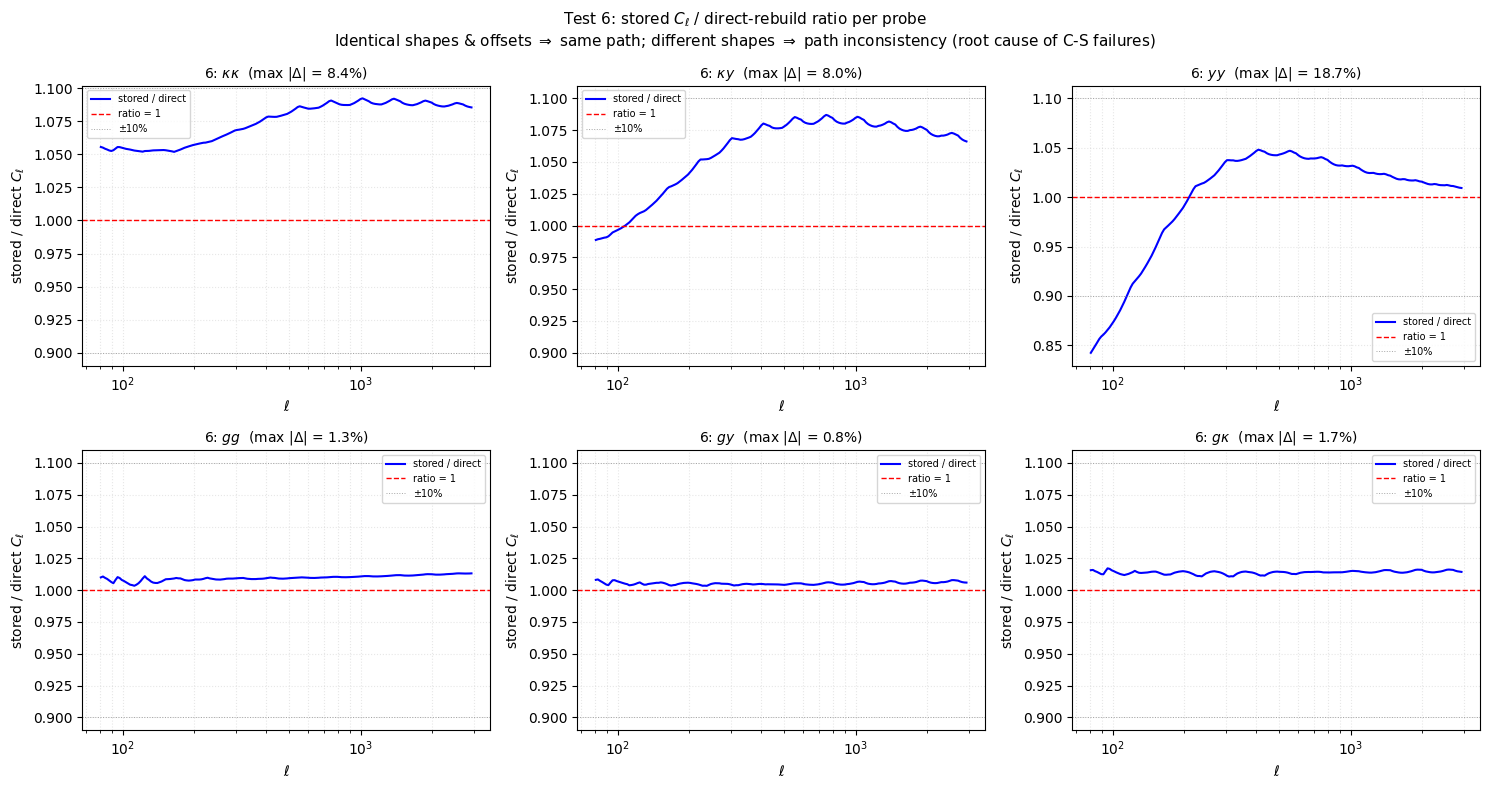

In [12]:
# =============================================================================
# TEST 6 — per-probe computation-path consistency
#
# Compares each stored Cl_*_mat attribute against a direct rebuild via
# _project_dl_from_pk using the model-total P(k,z).  A ~8% systematic offset
# is expected from the z-grid mismatch (Test 5B).
#
# Diagnostic: if ALL six probes have SIMILAR offsets, they all use the same
# stored 2D-interp path → C-S failures in Test 5C arise from z-grid mismatch
# affecting kk, gk, gg by different fractional amounts.
# If gk (or gy) has a VERY DIFFERENT offset, it uses a different path →
# path inconsistency is the direct cause of the C-S failures.
# =============================================================================

ell_t6  = np.asarray(Cls_test.ell_array)
efac_t6 = ell_t6 * (ell_t6 + 1) / (2 * np.pi)

# model-total P(k,z) for each probe  (helpers from cell 51c1437e)
_Pk_probe = {
    'kk': _kk_total_pk(),
    'ky': _ky_total_pk(),
    'yy': _yy_total_pk(),
    'gg': _gg_total_pk(),
    'gy': _gy_total_pk(),
    'gk': _gk_total_pk(),
}

def _direct_cl(Pkz, W1, W2, bp=0):
    """Direct Limber C_ell via _project_dl_from_pk (returns C_ell, not D_ell)."""
    return _project_dl_from_pk(Pkz, W1, W2, beam_pow=bp) / efac_t6

# stored signal C_ell, bin (0,0) or bin 0
_stored_t6 = {
    'yy': np.asarray(Cls_test.Cl_y_y_signal_mat),
    'ky': np.asarray(Cls_test.Cl_kappa_y_tot_mat)[:, 0],
    'kk': np.asarray(Cls_test.Cl_kappa_kappa_tot_mat)[:, 0, 0],
    'gy': np.asarray(Cls_test.Cl_gal_y_tot_mat)[:, 0],
    'gk': np.asarray(Cls_test.Cl_gal_kappa_tot_mat)[:, 0, 0],
    'gg': np.asarray(Cls_test.Cl_gal_gal_tot_mat)[:, 0, 0],
}

_direct_t6 = {
    'yy': _direct_cl(_Pk_probe['yy'], _Wy_eff,    _Wy_eff,    bp=2),
    'ky': _direct_cl(_Pk_probe['ky'], _Wk_eff[0], _Wy_eff,    bp=1),
    'kk': _direct_cl(_Pk_probe['kk'], _Wk_eff[0], _Wk_eff[0], bp=0),
    'gy': _direct_cl(_Pk_probe['gy'], _Wg_eff[0], _Wy_eff,    bp=1),
    'gk': _direct_cl(_Pk_probe['gk'], _Wg_eff[0], _Wk_eff[0], bp=0),
    'gg': _direct_cl(_Pk_probe['gg'], _Wg_eff[0], _Wg_eff[0], bp=0),
}

_ratios_t6   = {}
_resid_pct_t6 = {}
for prb in _stored_t6:
    s = _stored_t6[prb]
    d = _direct_t6[prb]
    with np.errstate(divide='ignore', invalid='ignore'):
        _ratios_t6[prb]    = np.where(np.abs(d) > 0, s / d, np.nan)
        _resid_pct_t6[prb] = np.where(np.abs(s) > 0, (s - d) / s * 100.0, np.nan)

probe_order_t6 = ['kk', 'ky', 'yy', 'gg', 'gy', 'gk']
print("TEST 6 — per-probe computation-path consistency")
print(f"  {'Probe':8s}  {'max |residual|':>16s}  {'ratio at mid-ell':>18s}")
print(f"  {'-'*50}")
for prb in probe_order_t6:
    mr   = np.nanmax(np.abs(_resid_pct_t6[prb]))
    mid  = len(ell_t6) // 2
    r_mid = float(_ratios_t6[prb][mid]) if np.isfinite(_ratios_t6[prb][mid]) else np.nan
    print(f"  {prb:8s}  {mr:14.2f} %  {r_mid:18.4f}")

# key comparison: are cross-probe residuals consistent with auto-probe residuals?
mr = {prb: np.nanmax(np.abs(_resid_pct_t6[prb])) for prb in probe_order_t6}

print()
print(f"  kk vs gk difference: {abs(mr['kk'] - mr['gk']):.2f} %")
print(f"  gg vs gk difference: {abs(mr['gg'] - mr['gk']):.2f} %")
print(f"  yy vs gy difference: {abs(mr['yy'] - mr['gy']):.2f} %")
print(f"  kk vs ky difference: {abs(mr['kk'] - mr['ky']):.2f} %")
print()

spread = max(mr['kk'], mr['gg'], mr['gk']) - min(mr['kk'], mr['gg'], mr['gk'])
if spread < 10.0:
    print("  All residuals within 10% of each other → same computation path.")
    print("  C-S failures in Test 5C arise because z-grid mismatch shifts kk,")
    print("  gk, gg by DIFFERENT fractional amounts (they have different k-shapes),")
    print("  breaking the projected C-S identity.")
else:
    print("  Large spread in residuals → different computation paths.")
    print("  Path inconsistency directly causes the Test 5C C-S failures.")
    print("  Fix: recompute all probes on the same z-grid before assembling M(ell).")

# ---- Plot -------------------------------------------------------------------
fig6, axes6 = plt.subplots(2, 3, figsize=(15, 8), squeeze=False)
probe_titles_t6 = {
    'kk': r'$\kappa\kappa$', 'ky': r'$\kappa y$', 'yy': r'$yy$',
    'gg': r'$gg$',           'gy': r'$gy$',        'gk': r'$g\kappa$',
}

for ax, prb in zip(axes6.flat, probe_order_t6):
    r  = _ratios_t6[prb]
    ax.semilogx(ell_t6, r, 'b-', lw=1.5, label='stored / direct')
    ax.axhline(1.0,  color='r',    lw=1.0, ls='--', label='ratio = 1')
    ax.axhline(0.9,  color='gray', lw=0.7, ls=':',  alpha=0.7)
    ax.axhline(1.1,  color='gray', lw=0.7, ls=':',  alpha=0.7, label='±10%')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'stored / direct $C_\ell$')
    title_str = f'6: {probe_titles_t6[prb]}  (max |Δ| = {mr[prb]:.1f}%)'
    ax.set_title(title_str, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, which='both', ls=':', alpha=0.3)

fig6.suptitle(
    'Test 6: stored $C_\\ell$ / direct-rebuild ratio per probe\n'
    r'Identical shapes & offsets $\Rightarrow$ same path; '
    r'different shapes $\Rightarrow$ path inconsistency (root cause of C-S failures)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIGDIR / 'test6_path_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

## Test 7 — decomposing stored-tot vs 1h+2h discrepancy: all probes

For each probe the gap between `Cl_*_mat` (stored total) and a direct Limber projection of `P_1h + P_2h` has exactly two contributions:

**(a) P-model correction** — the stored path uses a corrected `P_tot`, not the raw sum:

| Probe | Correction | Model flag |
|-------|-----------|------------|
| `kk`, `gg`, `gk` | `P_tot = (P_1h + P_2h) × S(k,z)` — Pmm_sup suppression | always |
| `ky`, `gy` | `P_tot = alpha_mix(P_1h, P_2h, α)` — no S since `tSZ_transition='poweradd'` | `α=1.0` → identical to 1h+2h |
| `yy` | `P_tot = P_1h + P_2h` | no correction |

**(b) z-grid mismatch** — the stored path trains a 2D interpolator on (`log k`, `z_hm`, 22 pts) then integrates over `z_cls` (128 pts). The direct path evaluates `k_ℓ = (ℓ+0.5)/χ(z_cls)` directly. The resulting k-shift amplifies differently per probe, set by `|d ln P / d ln k|` at the relevant k values — steep probes (yy with B², kk with S(k)) are most sensitive.

**Decomposition (exact):**
```
stored / direct_raw = (stored / direct_tot) × (direct_tot / direct_raw)
                    =     z-grid factor      ×    P-model correction
```

TEST 7 — stored-tot vs 1h+2h decomposition (max |deviation| per probe)

           stored/raw       tot/raw    stored/tot  P-model correction
  ------------------------------------------------------------------------------
  kk           8.95%        8.61%        9.22%  × Pmm_sup  S(k,z)
  ky           8.70%        0.00%        8.70%  α=1, poweradd  → none
  yy          15.75%        0.00%       15.75%  none
  gg           9.70%       10.44%        1.32%  × Pmm_sup  S(k,z)
  gy           0.84%        0.00%        0.84%  α=1, poweradd  → none
  gk           8.79%        9.92%        1.72%  × Pmm_sup  S(k,z)

  tot/raw    = P-model correction (S suppression, or ~0 for yy/ky/gy)
  stored/tot = z-grid + 2D-interp mismatch (same P, different chi grids)
  stored/raw = stored/tot × tot/raw  [exact product decomposition]

  Decomposition check  max |stored/raw − (stored/tot × tot/raw)|:
    kk: 2.22e-16
    ky: 0.00e+00
    yy: 0.00e+00
    gg: 2.22e-16
    gy: 0.00e+00
    gk: 2.22e-16


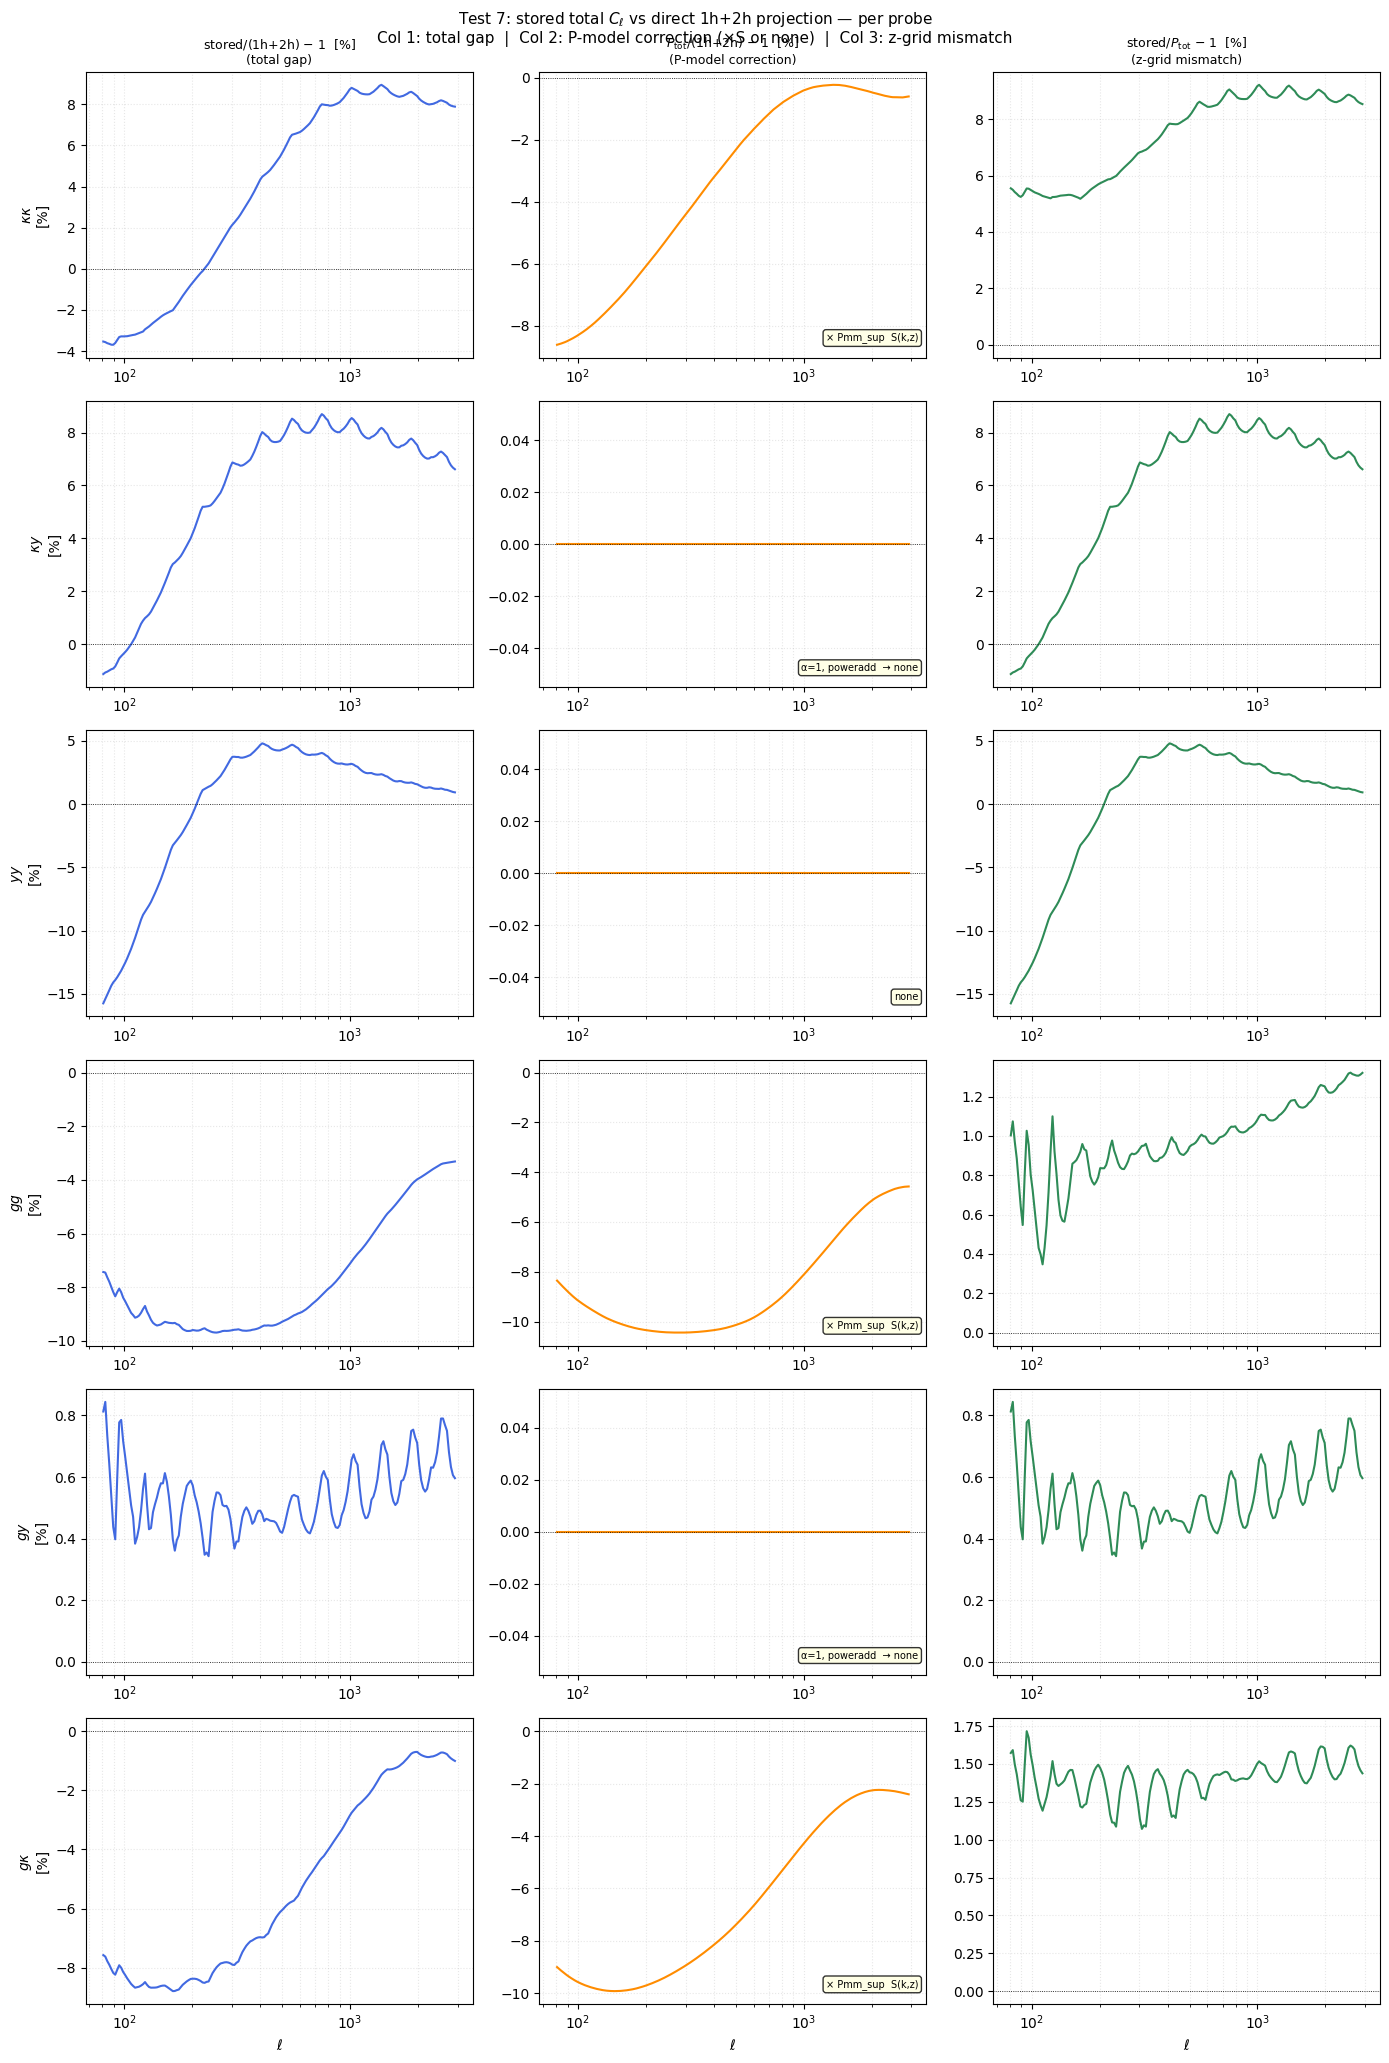

In [13]:
# =============================================================================
# TEST 7 — stored-tot vs 1h+2h discrepancy decomposition for all probes
# =============================================================================

ell_t7  = np.asarray(Cls_test.ell_array)
efac_t7 = ell_t7 * (ell_t7 + 1) / (2 * np.pi)

# --- raw 1h+2h P(k,z): no S, no alpha corrections ---------------------------
_P_raw_t7 = {
    'kk': np.asarray(Cls_test.Pmm_dmb_1h_kz_mat) + np.asarray(Cls_test.Pmm_dmb_2h_kz_mat),
    'ky': np.asarray(Cls_test.Pym_1h_kz_mat)      + np.asarray(Cls_test.Pym_2h_kz_mat),
    'yy': np.asarray(Cls_test.Pyy_1h_kz_mat)      + np.asarray(Cls_test.Pyy_2h_kz_mat),
    'gg': np.asarray(Cls_test.Pgg_1h_kz_mat)      + np.asarray(Cls_test.Pgg_2h_kz_mat),
    'gy': np.asarray(Cls_test.Pgy_1h_kz_mat)      + np.asarray(Cls_test.Pgy_2h_kz_mat),
    'gk': np.asarray(Cls_test.Pgm_1h_kz_mat)      + np.asarray(Cls_test.Pgm_2h_kz_mat),
}

# --- model-total P(k,z): with S for kk/gg/gk; == raw for yy/ky/gy -----------
_P_tot_t7 = {
    'kk': _kk_total_pk(), 'ky': _ky_total_pk(), 'yy': _yy_total_pk(),
    'gg': _gg_total_pk(), 'gy': _gy_total_pk(), 'gk': _gk_total_pk(),
}

_bp_t7     = {'kk': 0, 'ky': 1, 'yy': 2, 'gg': 0, 'gy': 1, 'gk': 0}
_Wpairs_t7 = {
    'kk': (_Wk_eff[0], _Wk_eff[0]),
    'ky': (_Wk_eff[0], _Wy_eff),
    'yy': (_Wy_eff,    _Wy_eff),
    'gg': (_Wg_eff[0], _Wg_eff[0]),
    'gy': (_Wg_eff[0], _Wy_eff),
    'gk': (_Wg_eff[0], _Wk_eff[0]),
}

_Cl_raw_t7 = {}
_Cl_tot_t7 = {}
for prb, (W1, W2) in _Wpairs_t7.items():
    bp = _bp_t7[prb]
    _Cl_raw_t7[prb] = _project_dl_from_pk(_P_raw_t7[prb], W1, W2, beam_pow=bp) / efac_t7
    _Cl_tot_t7[prb] = _project_dl_from_pk(_P_tot_t7[prb], W1, W2, beam_pow=bp) / efac_t7

# stored signal Cl (from Test 6)
_Cl_stored_t7 = {p: _stored_t6[p] for p in _stored_t6}

# --- percentage deviations from 1 -------------------------------------------
def _pct(num, den):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(np.abs(den) > 0, (num / den - 1.0) * 100.0, np.nan)

probe_order_t7 = ['kk', 'ky', 'yy', 'gg', 'gy', 'gk']
probe_sym_t7   = {'kk': r'$\kappa\kappa$', 'ky': r'$\kappa y$', 'yy': r'$yy$',
                  'gg': r'$gg$',           'gy': r'$gy$',        'gk': r'$g\kappa$'}

_dev_sr = {p: _pct(_Cl_stored_t7[p], _Cl_raw_t7[p]) for p in probe_order_t7}   # stored/raw − 1
_dev_tr = {p: _pct(_Cl_tot_t7[p],    _Cl_raw_t7[p]) for p in probe_order_t7}   # tot/raw   − 1  (correction)
_dev_st = {p: _pct(_Cl_stored_t7[p], _Cl_tot_t7[p]) for p in probe_order_t7}   # stored/tot − 1 (z-grid)

_corr_t7 = {
    'kk': '× Pmm_sup  S(k,z)',
    'ky': 'α=1, poweradd  → none',
    'yy': 'none',
    'gg': '× Pmm_sup  S(k,z)',
    'gy': 'α=1, poweradd  → none',
    'gk': '× Pmm_sup  S(k,z)',
}

# --- summary table -----------------------------------------------------------
print("TEST 7 — stored-tot vs 1h+2h decomposition (max |deviation| per probe)")
print()
print(f"  {'':5s}  {'stored/raw':>12s}  {'tot/raw':>12s}  {'stored/tot':>12s}  P-model correction")
print(f"  {'-'*78}")
for p in probe_order_t7:
    a = np.nanmax(np.abs(_dev_sr[p]))
    b = np.nanmax(np.abs(_dev_tr[p]))
    c = np.nanmax(np.abs(_dev_st[p]))
    print(f"  {p:5s}  {a:10.2f}%  {b:10.2f}%  {c:10.2f}%  {_corr_t7[p]}")

print()
print("  tot/raw    = P-model correction (S suppression, or ~0 for yy/ky/gy)")
print("  stored/tot = z-grid + 2D-interp mismatch (same P, different chi grids)")
print("  stored/raw = stored/tot × tot/raw  [exact product decomposition]")

# verify decomposition is exact
print()
print("  Decomposition check  max |stored/raw − (stored/tot × tot/raw)|:")
for p in probe_order_t7:
    s  = _Cl_stored_t7[p]
    dr = _Cl_raw_t7[p]
    dt = _Cl_tot_t7[p]
    with np.errstate(divide='ignore', invalid='ignore'):
        lhs = np.where(np.abs(dr) > 0, s / dr, np.nan)
        rhs = np.where(np.abs(dt) > 0, (s / dt) * (dt / dr), np.nan)
    err = np.nanmax(np.abs(lhs - rhs))
    print(f"    {p}: {err:.2e}")

# --- plot: 6 rows × 3 columns -----------------------------------------------
fig7, axes7 = plt.subplots(len(probe_order_t7), 3, figsize=(14, 3.5 * len(probe_order_t7)))

col_labels = [
    r'stored$/$(1h+2h) $-$ 1  [%]' + '\n(total gap)',
    r'$P_{\rm tot}$/(1h+2h) $-$ 1  [%]' + '\n(P-model correction)',
    r'stored$/P_{\rm tot}$ $-$ 1  [%]' + '\n(z-grid mismatch)',
]
col_colors = ['royalblue', 'darkorange', 'seagreen']

for row, p in enumerate(probe_order_t7):
    devs = [_dev_sr[p], _dev_tr[p], _dev_st[p]]
    for col, (dev, clr) in enumerate(zip(devs, col_colors)):
        ax = axes7[row, col]
        ax.semilogx(ell_t7, dev, color=clr, lw=1.5)
        ax.axhline(0, color='k', lw=0.6, ls=':')
        ax.set_xlabel(r'$\ell$' if row == len(probe_order_t7) - 1 else '')
        ax.grid(True, which='both', ls=':', alpha=0.3)
        if row == 0:
            ax.set_title(col_labels[col], fontsize=9)
        if col == 0:
            ax.set_ylabel(probe_sym_t7[p] + '\n[%]', fontsize=10)
        # annotate correction label on middle column
        if col == 1:
            ax.text(0.98, 0.05, _corr_t7[p], transform=ax.transAxes,
                    fontsize=7, ha='right', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

fig7.suptitle(
    'Test 7: stored total $C_\\ell$ vs direct 1h+2h projection — per probe\n'
    'Col 1: total gap  |  Col 2: P-model correction (×S or none)  |  Col 3: z-grid mismatch',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIGDIR / 'test7_1h2h_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

TEST 8 -- z_hm projection vs stored: residual decomposition

          (A) stored/zhm     (B) zhm/zcls   stored/zcls (T7)
  ----------------------------------------------------------
  kk                2.61%            11.22%               9.22%
  ky                5.10%             5.93%               8.70%
  yy                8.99%            20.01%              15.75%
  gg               13.64%            17.07%               1.32%
  gy                4.62%             5.66%               0.84%
  gk                6.13%             8.26%               1.72%

  (A) stored/zhm  = z-quadrature difference only (22 vs 128 pts, same chi)
  (B) zhm/zcls    = k_ell shift from chi(z_hm) vs chi(z_cls)
  stored/zcls     = (A) x (B)  [exact]

  If (A) << stored/zcls: k_ell chi-shift (B) is the dominant driver
  If (A) ~  stored/zcls: z-quadrature resolution dominates

  Decomposition check  max |(A)x(B) - stored/zcls|:
    kk: 2.22e-16
    ky: 2.22e-16
    yy: 2.22e-16
    gg: 2.22e-16
    gy: 

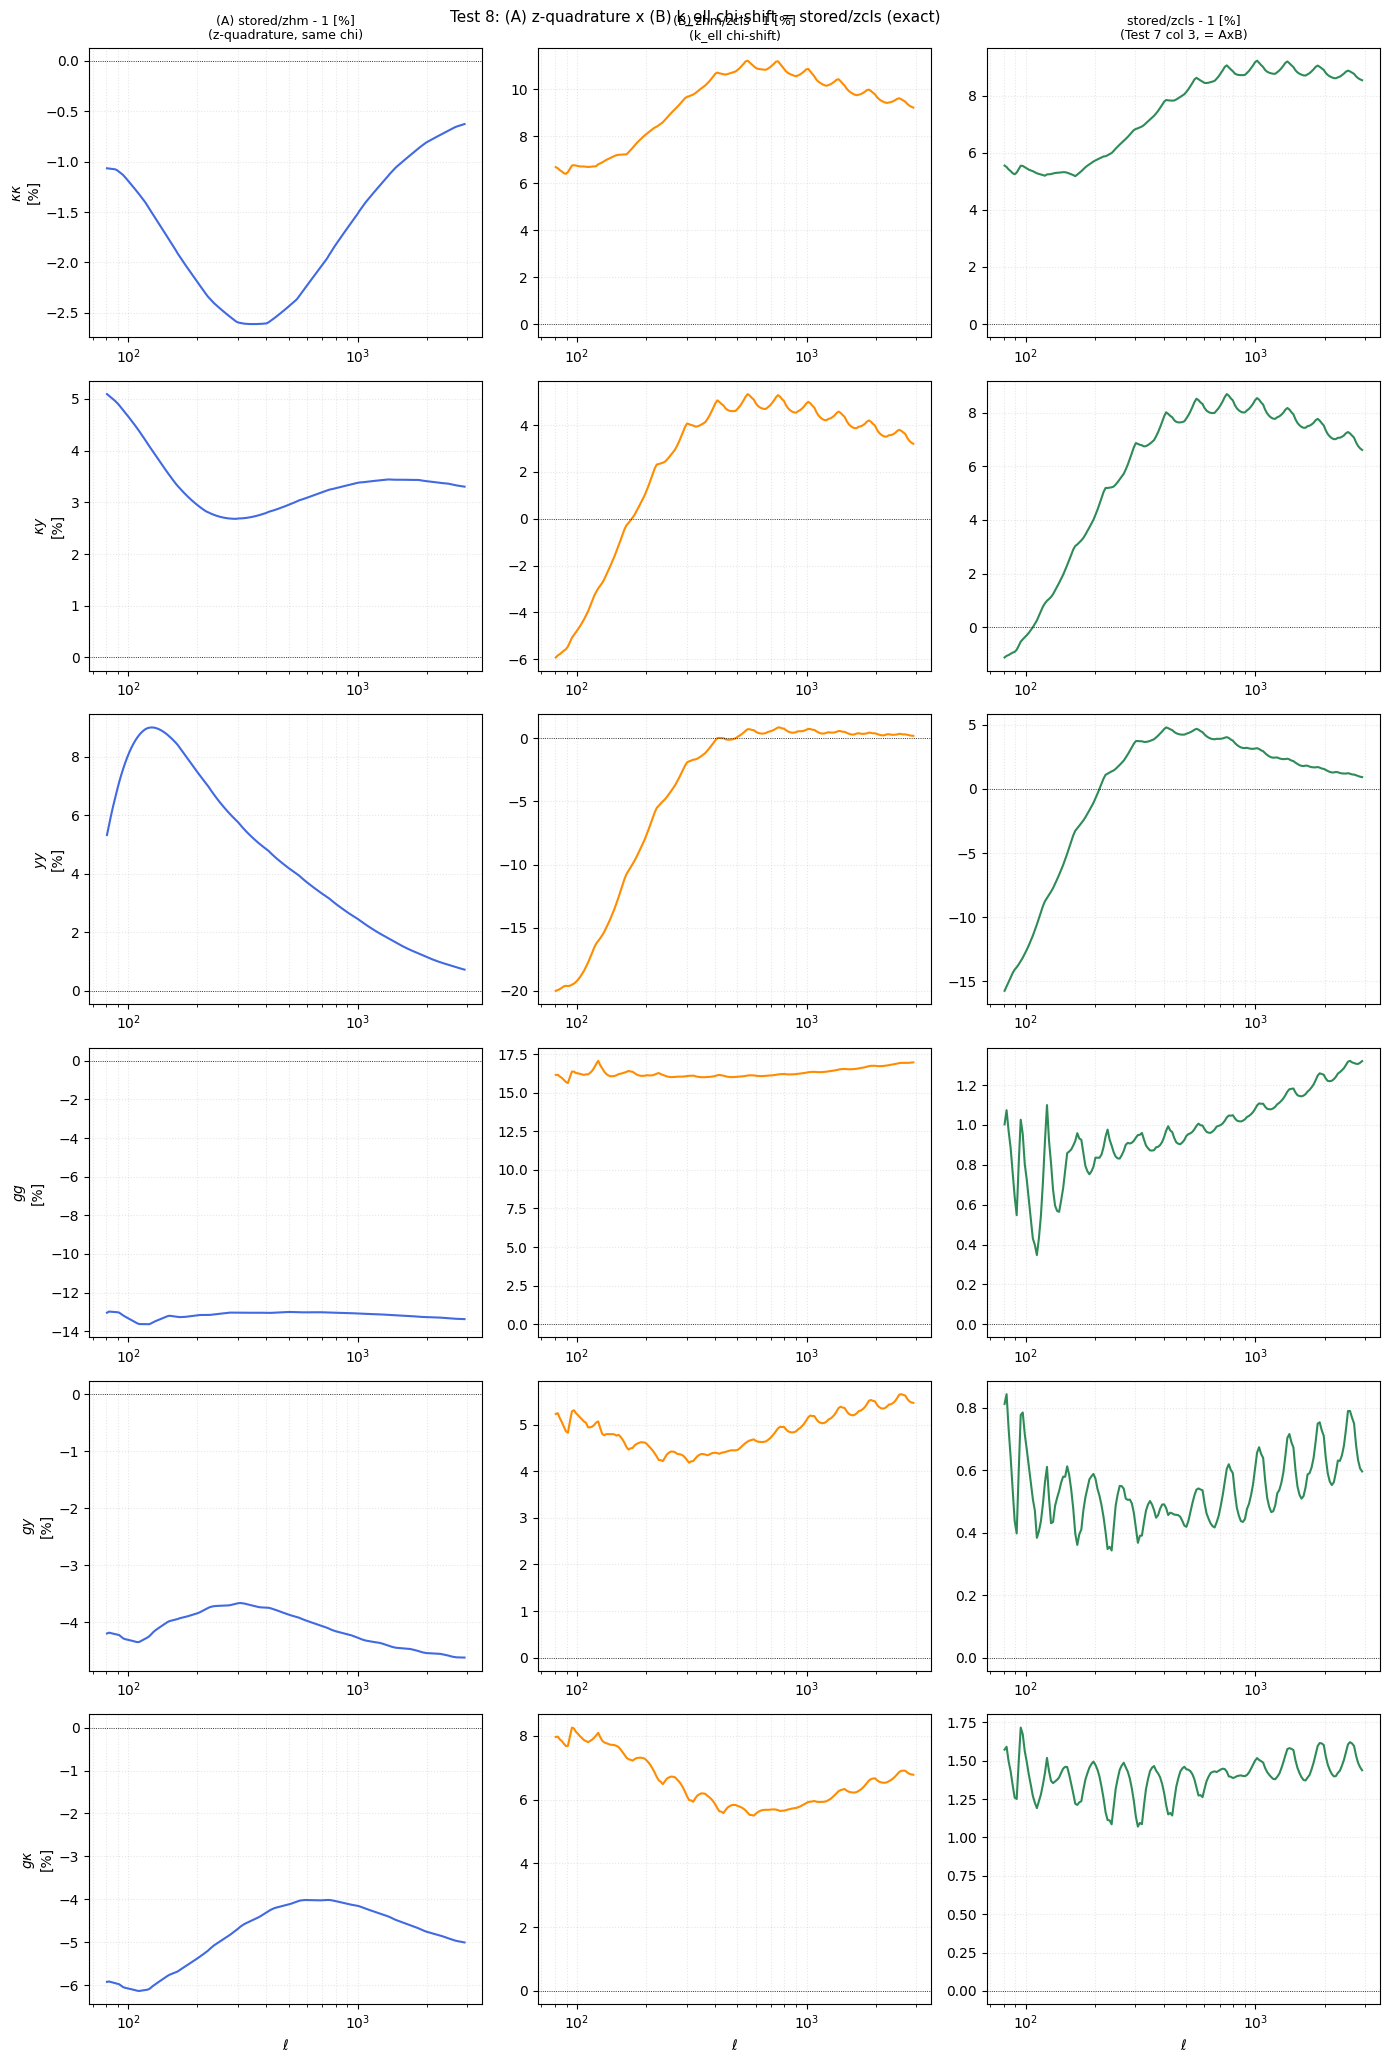

In [14]:
# =============================================================================
# TEST 8 — does projecting P_tot on z_hm (matching chi grid of stored path)
#           recover the stored Cl to <1%?
#
# Decomposition of the Test 7 'stored/zcls' residual into two factors:
#   (A) stored / zhm  : same chi for k_ell; differs only in z-quadrature
#                       (stored integrates 128 pts; zhm integrates 22 pts)
#   (B) zhm / zcls    : same P, chi(z_hm) vs chi(z_cls) for k_ell
#   stored / zcls = (A) x (B)  [exact]
# =============================================================================

ell_t8     = np.asarray(Cls_test.ell_array)
efac_t8    = ell_t8 * (ell_t8 + 1) / (2 * np.pi)
z_hm_t8    = np.asarray(Cls_test.z_array)
chi_hm_t8  = np.asarray(Cls_test.chi_array)
kPk_t8     = np.asarray(Cls_test.kPk_array)
z_cls_t8   = np.asarray(Cls_test.z_array_for_Cls)
Bl_t8      = np.exp(-0.5 * ell_t8*(ell_t8+1) * float(Cls_test.sig_beam)**2)
dchi_hm_t8 = np.gradient(chi_hm_t8, z_hm_t8)

# window functions at z_hm
Wy_hm_t8 = (1.0/(1.0 + z_hm_t8)) / np.maximum(chi_hm_t8**2, 1e-20)
Wk_hm_t8 = np.interp(z_hm_t8, z_cls_t8, _Wk_eff[0])
Wg_hm_t8 = np.interp(z_hm_t8, z_cls_t8, _Wg_eff[0])

_Wpairs_hm = {
    'kk': (Wk_hm_t8, Wk_hm_t8), 'ky': (Wk_hm_t8, Wy_hm_t8), 'yy': (Wy_hm_t8, Wy_hm_t8),
    'gg': (Wg_hm_t8, Wg_hm_t8), 'gy': (Wg_hm_t8, Wy_hm_t8), 'gk': (Wg_hm_t8, Wk_hm_t8),
}

def _project_on_zhm(P_kz_hm, W1h, W2h, bp=0):
    P    = np.maximum(np.asarray(P_kz_hm), 1e-100)
    lkpk = np.log(kPk_t8)
    lP   = np.log(P)
    k_ell_hm = np.outer(ell_t8 + 0.5, 1.0 / np.maximum(chi_hm_t8, 1.0))
    lk_ell   = np.log(np.maximum(k_ell_hm, 1e-100))
    Pk_lz = np.zeros((len(ell_t8), len(z_hm_t8)))
    for iz in range(len(z_hm_t8)):
        Pk_lz[:, iz] = np.exp(np.interp(lk_ell[:, iz], lkpk, lP[:, iz]))
    if bp == 1:   Pk_lz *= Bl_t8[:, None]
    elif bp == 2: Pk_lz *= (Bl_t8**2)[:, None]
    integrand = W1h[None,:]*W2h[None,:]*chi_hm_t8[None,:]**2*dchi_hm_t8[None,:]*Pk_lz
    return np.trapezoid(integrand, z_hm_t8, axis=1)

_Cl_zhm_t8 = {p: _project_on_zhm(_P_tot_t7[p], *_Wpairs_hm[p], bp=_bp_t7[p]) for p in probe_order_t7}

_dev_A = {p: _pct(_Cl_stored_t7[p], _Cl_zhm_t8[p]) for p in probe_order_t7}
_dev_B = {p: _pct(_Cl_zhm_t8[p],   _Cl_tot_t7[p]) for p in probe_order_t7}

print('TEST 8 -- z_hm projection vs stored: residual decomposition')
print()
print(f"  {'':5s}  {'(A) stored/zhm':>15s}  {'(B) zhm/zcls':>15s}  {'stored/zcls (T7)':>17s}")
print(f"  {'-'*58}")
for p in probe_order_t7:
    a = np.nanmax(np.abs(_dev_A[p]))
    b = np.nanmax(np.abs(_dev_B[p]))
    c = np.nanmax(np.abs(_dev_st[p]))
    print(f'  {p:5s}  {a:15.2f}%  {b:15.2f}%  {c:17.2f}%')

print()
print('  (A) stored/zhm  = z-quadrature difference only (22 vs 128 pts, same chi)')
print('  (B) zhm/zcls    = k_ell shift from chi(z_hm) vs chi(z_cls)')
print('  stored/zcls     = (A) x (B)  [exact]')
print()
print('  If (A) << stored/zcls: k_ell chi-shift (B) is the dominant driver')
print('  If (A) ~  stored/zcls: z-quadrature resolution dominates')
print()
print('  Decomposition check  max |(A)x(B) - stored/zcls|:')
for p in probe_order_t7:
    with np.errstate(divide='ignore', invalid='ignore'):
        AB = np.where(np.abs(_Cl_tot_t7[p])>0, (_Cl_stored_t7[p]/_Cl_zhm_t8[p])*(_Cl_zhm_t8[p]/_Cl_tot_t7[p]), np.nan)
        sc = np.where(np.abs(_Cl_tot_t7[p])>0, _Cl_stored_t7[p]/_Cl_tot_t7[p], np.nan)
    print(f'    {p}: {np.nanmax(np.abs(AB - sc)):.2e}')

fig8, axes8 = plt.subplots(len(probe_order_t7), 3, figsize=(14, 3.5*len(probe_order_t7)))
col_lbl8 = [
    '(A) stored/zhm - 1 [%]\n(z-quadrature, same chi)',
    '(B) zhm/zcls - 1 [%]\n(k_ell chi-shift)',
    'stored/zcls - 1 [%]\n(Test 7 col 3, = AxB)',
]
col_clr8 = ['royalblue', 'darkorange', 'seagreen']
for row, p in enumerate(probe_order_t7):
    for col, (dat, clr, lbl) in enumerate(zip([_dev_A[p], _dev_B[p], _dev_st[p]], col_clr8, col_lbl8)):
        ax = axes8[row, col]
        ax.semilogx(ell_t8, dat, color=clr, lw=1.5)
        ax.axhline(0, color='k', lw=0.6, ls=':')
        ax.set_xlabel(r'$\ell$' if row == len(probe_order_t7)-1 else '')
        ax.grid(True, which='both', ls=':', alpha=0.3)
        if row == 0: ax.set_title(lbl, fontsize=9)
        if col == 0: ax.set_ylabel(probe_sym_t7[p]+'\n[%]', fontsize=10)
fig8.suptitle('Test 8: (A) z-quadrature x (B) k_ell chi-shift = stored/zcls (exact)', fontsize=11)
plt.tight_layout()
plt.savefig(FIGDIR / 'test8_zgrid_decomp.png', dpi=150, bbox_inches='tight')
plt.show()


TEST 9A — Fix 1: unified z-grid (z_cls → z_hm, 22 pts)

  (i)  Fix1 vs stored  [change from current implementation]
  Probe       max |residual|    ratio at mid-ell
  --------------------------------------------------
  kk                  2.68 %              1.0251
  ky                  4.85 %              0.9715
  yy                  8.25 %              0.9593
  gg                 15.79 %              1.1496
  gy                  4.85 %              1.0401
  gk                  6.53 %              1.0431

  (ii) Fix1 vs raw_zhm  [residual = P-model correction only]
  Probe       max |residual|    ratio at mid-ell
  --------------------------------------------------
  kk                  9.02 %              0.9828
  ky                  0.00 %              1.0000
  yy                  0.00 %              1.0000
  gg                 10.49 %              0.8979
  gy                  0.00 %              1.0000
  gk                 10.03 %              0.9232

  kk vs gk difference (vs sto

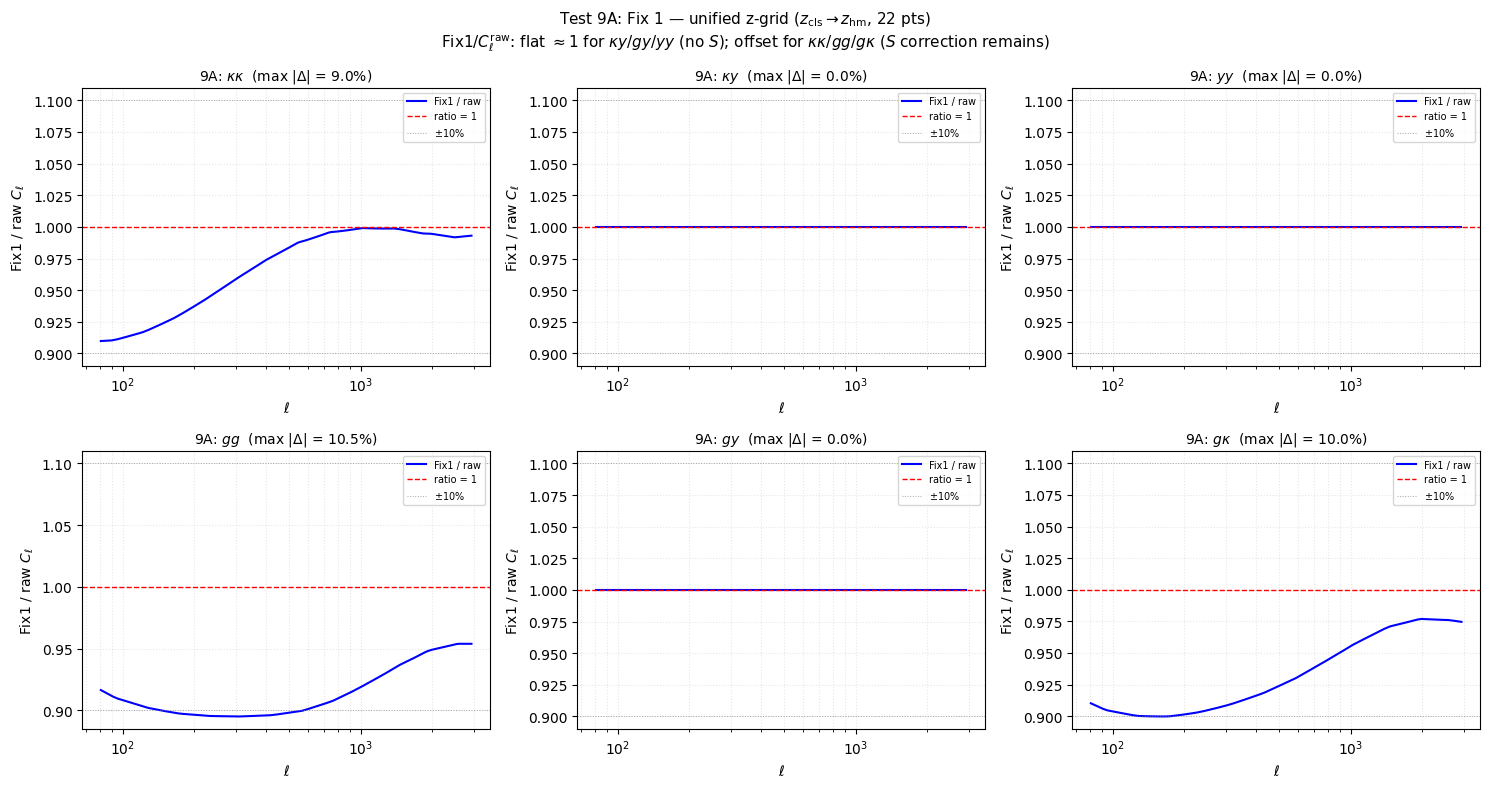

In [15]:
# =============================================================================
# TEST 9A — Fix 1: unified z-grid  (z_array_for_Cls → z_array, 22 pts)
#
# Eliminates BOTH z-quadrature (A) and chi-shift (B) simultaneously.
# Fix1_Cl = _Cl_zhm_t8[p]  (P_tot projected on z_hm, already in Test 8)
# Reference raw: project P_raw (1h+2h, no corrections) on z_hm.
#
# Table 1: Fix1 vs stored      → amplitude of z-grid fix per probe
# Table 2: Fix1 vs raw (z_hm)  → residual = P-model correction only
# Plot   : 2×3  Fix1/raw_zhm  (mirrors Test 6 layout)
# =============================================================================

_Cl_raw_zhm_t9 = {p: _project_on_zhm(_P_raw_t7[p], *_Wpairs_hm[p], bp=_bp_t7[p])
                  for p in probe_order_t7}

_res_9a_stored = {p: _pct(_Cl_zhm_t8[p], _Cl_stored_t7[p]) for p in probe_order_t7}
_res_9a_raw    = {p: _pct(_Cl_zhm_t8[p], _Cl_raw_zhm_t9[p]) for p in probe_order_t7}
_rat_9a_stored = {p: np.where(np.abs(_Cl_stored_t7[p]) > 0,
                               _Cl_zhm_t8[p] / _Cl_stored_t7[p], np.nan)
                  for p in probe_order_t7}
_rat_9a_raw    = {p: np.where(np.abs(_Cl_raw_zhm_t9[p]) > 0,
                               _Cl_zhm_t8[p] / _Cl_raw_zhm_t9[p], np.nan)
                  for p in probe_order_t7}

ell_t9 = ell_t8


def _print_table_9(label, resid_d, rat_d, probe_order, ell_arr):
    mid = len(ell_arr) // 2
    print(label)
    print(f"  {'Probe':8s}  {'max |residual|':>16s}  {'ratio at mid-ell':>18s}")
    print(f"  {'-'*50}")
    mr = {}
    for p in probe_order:
        mr[p] = np.nanmax(np.abs(resid_d[p]))
        r_mid = float(rat_d[p][mid]) if np.isfinite(rat_d[p][mid]) else np.nan
        print(f"  {p:8s}  {mr[p]:14.2f} %  {r_mid:18.4f}")
    return mr


print("TEST 9A — Fix 1: unified z-grid (z_cls → z_hm, 22 pts)")
print()
mr9a_s = _print_table_9(
    "  (i)  Fix1 vs stored  [change from current implementation]",
    _res_9a_stored, _rat_9a_stored, probe_order_t7, ell_t9)
print()
mr9a_r = _print_table_9(
    "  (ii) Fix1 vs raw_zhm  [residual = P-model correction only]",
    _res_9a_raw, _rat_9a_raw, probe_order_t7, ell_t9)

print()
print(f"  kk vs gk difference (vs stored):    {abs(mr9a_s['kk'] - mr9a_s['gk']):.2f} %")
print(f"  kk vs gk difference (vs raw_zhm):   {abs(mr9a_r['kk'] - mr9a_r['gk']):.2f} %")
print(f"  yy vs gy difference (vs raw_zhm):   {abs(mr9a_r['yy'] - mr9a_r['gy']):.2f} %")
print(f"  kk vs ky difference (vs raw_zhm):   {abs(mr9a_r['kk'] - mr9a_r['ky']):.2f} %")
print()

tsy_max_9a = max(mr9a_r['ky'], mr9a_r['gy'], mr9a_r['yy'])
if tsy_max_9a < 1.0:
    print(f"  ky/gy/yy max residual vs raw: {tsy_max_9a:.2f}% < 1%")
    print("  → Fix 1 fully resolves tSZ-probe gap (no S correction → should be ~0).")
else:
    print(f"  ky/gy/yy max residual vs raw: {tsy_max_9a:.2f}%")
    print("  → Unexpected — 22-pt quadrature may be insufficient even on unified grid.")

spread_9a = (max(mr9a_r['kk'], mr9a_r['gg'], mr9a_r['gk'])
           - min(mr9a_r['kk'], mr9a_r['gg'], mr9a_r['gk']))
if spread_9a < 2.0:
    print(f"  kk/gg/gk spread vs raw: {spread_9a:.1f}% < 2%")
    print("  → Fix 1 equalises lensing+galaxy probes; residual = S(k,z) only.")
else:
    print(f"  kk/gg/gk spread vs raw: {spread_9a:.1f}%")
    print("  → 22-pt quadrature still introduces probe-dependent differences.")

# ── plot: Fix1 / raw_zhm  (mirrors Test 6) ──────────────────────────────
fig9a, axes9a = plt.subplots(2, 3, figsize=(15, 8), squeeze=False)
_sym9 = probe_sym_t7

for ax, p in zip(axes9a.flat, probe_order_t7):
    r = _rat_9a_raw[p]
    ax.semilogx(ell_t9, r, 'b-', lw=1.5, label='Fix1 / raw')
    ax.axhline(1.0, color='r',    lw=1.0, ls='--', label='ratio = 1')
    ax.axhline(0.9, color='gray', lw=0.7, ls=':',  alpha=0.7)
    ax.axhline(1.1, color='gray', lw=0.7, ls=':',  alpha=0.7, label=r'$\pm$10%')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'Fix1 / raw $C_\ell$')
    ax.set_title(f'9A: {_sym9[p]}  (max |\u0394| = {mr9a_r[p]:.1f}%)', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, which='both', ls=':', alpha=0.3)

fig9a.suptitle(
    'Test 9A: Fix 1 — unified z-grid ($z_{\\rm cls} \\to z_{\\rm hm}$, 22 pts)\n'
    r'Fix1/$C_\ell^{\rm raw}$: flat $\approx 1$ for $\kappa y/gy/yy$ (no $S$); '
    r'offset for $\kappa\kappa/gg/g\kappa$ ($S$ correction remains)',
    fontsize=11)
plt.tight_layout()
plt.savefig(FIGDIR / 'test9a_fix1_unified_grid.png', dpi=150, bbox_inches='tight')
plt.show()


TEST 9B — Fix 2: correct k_ell  (chi(z_cls) throughout, 128-pt z_cls)

  (i)  Fix2 vs stored  [change from current implementation]
  Probe       max |residual|    ratio at mid-ell
  --------------------------------------------------
  kk                  8.44 %              0.9255
  ky                  8.00 %              0.9286
  yy                 18.70 %              0.9593
  gg                  1.30 %              0.9908
  gy                  0.84 %              0.9958
  gk                  1.69 %              0.9856

  (ii) Fix2 vs raw_zcls  [residual = P-model correction only]
  Probe       max |residual|    ratio at mid-ell
  --------------------------------------------------
  kk                  8.61 %              0.9761
  ky                  0.00 %              1.0000
  yy                  0.00 %              1.0000
  gg                 10.44 %              0.8983
  gy                  0.00 %              1.0000
  gk                  9.92 %              0.9253

  kk vs gk di

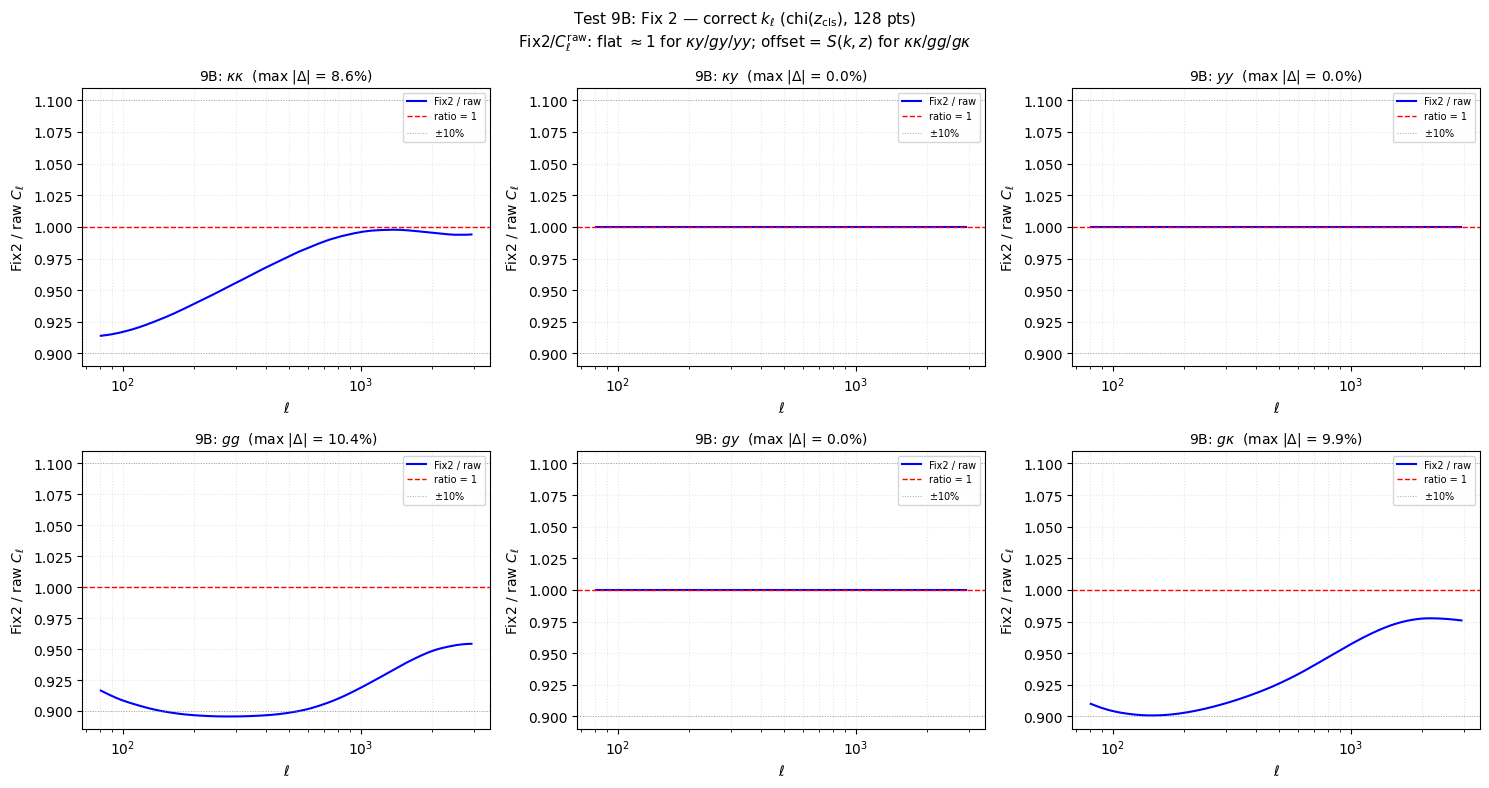

In [16]:
# =============================================================================
# TEST 9B — Fix 2: correct k_ell  (use chi(z_cls) for k_ell; keep 128-pt z_cls)
#
# Eliminates the chi-shift (B) error only; retains 128-pt quadrature.
# Fix2_Cl = _Cl_tot_t7[p]  (P_tot direct projection on z_cls, from Test 7)
# Reference raw = _Cl_raw_t7[p]  (1h+2h on z_cls, from Test 7)
#
# Table 1: Fix2 vs stored      → amplitude of chi-correction per probe
# Table 2: Fix2 vs raw (z_cls) → residual = P-model correction only
# Plot   : 2×3  Fix2/raw_zcls  (mirrors Test 6 layout)
# =============================================================================

_res_9b_stored = {p: _pct(_Cl_tot_t7[p], _Cl_stored_t7[p]) for p in probe_order_t7}
_res_9b_raw    = {p: _pct(_Cl_tot_t7[p], _Cl_raw_t7[p])    for p in probe_order_t7}
_rat_9b_stored = {p: np.where(np.abs(_Cl_stored_t7[p]) > 0,
                               _Cl_tot_t7[p] / _Cl_stored_t7[p], np.nan)
                  for p in probe_order_t7}
_rat_9b_raw    = {p: np.where(np.abs(_Cl_raw_t7[p]) > 0,
                               _Cl_tot_t7[p] / _Cl_raw_t7[p], np.nan)
                  for p in probe_order_t7}

print("TEST 9B — Fix 2: correct k_ell  (chi(z_cls) throughout, 128-pt z_cls)")
print()
mr9b_s = _print_table_9(
    "  (i)  Fix2 vs stored  [change from current implementation]",
    _res_9b_stored, _rat_9b_stored, probe_order_t7, ell_t9)
print()
mr9b_r = _print_table_9(
    "  (ii) Fix2 vs raw_zcls  [residual = P-model correction only]",
    _res_9b_raw, _rat_9b_raw, probe_order_t7, ell_t9)

print()
print(f"  kk vs gk difference (vs stored):    {abs(mr9b_s['kk'] - mr9b_s['gk']):.2f} %")
print(f"  kk vs gk difference (vs raw_zcls):  {abs(mr9b_r['kk'] - mr9b_r['gk']):.2f} %")
print(f"  yy vs gy difference (vs raw_zcls):  {abs(mr9b_r['yy'] - mr9b_r['gy']):.2f} %")
print(f"  kk vs ky difference (vs raw_zcls):  {abs(mr9b_r['kk'] - mr9b_r['ky']):.2f} %")
print()

tsy_max_9b = max(mr9b_r['ky'], mr9b_r['gy'], mr9b_r['yy'])
if tsy_max_9b < 1.0:
    print(f"  ky/gy/yy max residual vs raw: {tsy_max_9b:.2f}% < 1%")
    print("  → Fix 2 fully resolves tSZ-probe gap (no S correction → should be ~0).")
else:
    print(f"  ky/gy/yy max residual vs raw: {tsy_max_9b:.2f}%")
    print("  → Residual in tSZ probes > 1% — check alpha / poweradd path.")

spread_9b = (max(mr9b_r['kk'], mr9b_r['gg'], mr9b_r['gk'])
           - min(mr9b_r['kk'], mr9b_r['gg'], mr9b_r['gk']))
if spread_9b < 2.0:
    print(f"  kk/gg/gk spread vs raw: {spread_9b:.1f}% < 2%")
    print("  → Fix 2 equalises lensing+galaxy probes; residual = S(k,z) only.")
else:
    print(f"  kk/gg/gk spread vs raw: {spread_9b:.1f}%")
    print("  → S(k,z) correction is probe-dependent (kk baryonified vs gk NFW).")
    print("    That is a physics difference, not a numerical artefact.")

# Fix 1 vs Fix 2 comparison for the worst probe (yy)
print()
print(f"  Fix 1 vs Fix 2 comparison (most-affected probes):")
for p in ['yy', 'kk', 'ky']:
    d_a = mr9a_r[p]
    d_b = mr9b_r[p]
    better = 'Fix2 better' if d_b < d_a else 'Fix1 sufficient'
    print(f"    {p}: Fix1 residual = {d_a:.2f}%  |  Fix2 residual = {d_b:.2f}%  [{better}]")

# ── plot: Fix2 / raw_zcls  (mirrors Test 6) ──────────────────────────────
fig9b, axes9b = plt.subplots(2, 3, figsize=(15, 8), squeeze=False)

for ax, p in zip(axes9b.flat, probe_order_t7):
    r = _rat_9b_raw[p]
    ax.semilogx(ell_t9, r, 'b-', lw=1.5, label='Fix2 / raw')
    ax.axhline(1.0, color='r',    lw=1.0, ls='--', label='ratio = 1')
    ax.axhline(0.9, color='gray', lw=0.7, ls=':',  alpha=0.7)
    ax.axhline(1.1, color='gray', lw=0.7, ls=':',  alpha=0.7, label=r'$\pm$10%')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'Fix2 / raw $C_\ell$')
    ax.set_title(f'9B: {_sym9[p]}  (max |\u0394| = {mr9b_r[p]:.1f}%)', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, which='both', ls=':', alpha=0.3)

fig9b.suptitle(
    'Test 9B: Fix 2 — correct $k_\\ell$ (chi($z_{\\rm cls}$), 128 pts)\n'
    r'Fix2/$C_\ell^{\rm raw}$: flat $\approx 1$ for $\kappa y/gy/yy$; '
    r'offset = $S(k,z)$ for $\kappa\kappa/gg/g\kappa$',
    fontsize=11)
plt.tight_layout()
plt.savefig(FIGDIR / 'test9b_fix2_correct_kell.png', dpi=150, bbox_inches='tight')
plt.show()
